<a href="https://colab.research.google.com/github/Pablozh123/deep-learning-Knochenstrukur/blob/main/2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# Zelle 1: Setup und Pfade
# =========================
# Ziel: Drive mounten, Pfade setzen, Existenz prüfen.

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, pandas as pd

BASE = '/content/drive/MyDrive'                 # dein Google Drive Stamm
CSV_PATH = f'{BASE}/datastats.csv'              # deine CSV
IMG_ROOT = f'{BASE}/DigitalHandAtlas'           # Ordner mit Bildern

assert os.path.isdir(IMG_ROOT), f'Bilderordner fehlt: {IMG_ROOT}'
assert os.path.isfile(CSV_PATH), f'CSV fehlt: {CSV_PATH}'

print('OK: Pfade vorhanden.')
print('BASE     :', BASE)
print('CSV_PATH :', CSV_PATH)
print('IMG_ROOT :', IMG_ROOT)


Mounted at /content/drive
OK: Pfade vorhanden.
BASE     : /content/drive/MyDrive
CSV_PATH : /content/drive/MyDrive/datastats.csv
IMG_ROOT : /content/drive/MyDrive/DigitalHandAtlas


In [ ]:
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import seaborn as sns
import os

# 1) Vorhersagen auf Test sammeln, Reihenfolge = Dataset-Reihenfolge
model.eval()
age_true, age_pred = [], []
eth_true, eth_pred, eth_conf = [], [], []

with torch.no_grad():
    for imgs, ages, races in test_loader:
        imgs = imgs.to(device)
        ages = ages.cpu().numpy()
        races = races.cpu().numpy()
        pa, pe = model(imgs)
        pa = pa.cpu().numpy()  # Removed .squeeze(1) as output is already 1D
        probs = F.softmax(pe, dim=1).cpu().numpy()
        preds = probs.argmax(1)
        confs = probs.max(1)

        age_true.append(ages); age_pred.append(pa)
        eth_true.append(races); eth_pred.append(preds); eth_conf.append(confs)

age_true = np.concatenate(age_true)
age_pred = np.concatenate(age_pred)
eth_true = np.concatenate(eth_true)
eth_pred = np.concatenate(eth_pred)
eth_conf = np.concatenate(eth_conf)

# Klassen-Namen
cls_names = list(le.classes_) if 'le' in globals() else [str(i) for i in np.unique(eth_true)]

# 2) Confusion Matrix normalisiert nach Zeile
cm = confusion_matrix(eth_true, eth_pred, labels=list(range(len(cls_names)))).astype(np.float32)
cm_n = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

plt.figure(figsize=(6,5))
sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues", xticklabels=cls_names, yticklabels=cls_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr"); plt.title("Confusion Matrix (Test, normiert)")
plt.tight_layout(); plt.show()

# 3) Top-Fehlpaare ausgeben
pairs = []
for i in range(len(cls_names)):
    for j in range(len(cls_names)):
        if i!=j:
            pairs.append(((cls_names[i], cls_names[j]), cm[i,j]))
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
print("Häufigste Verwechslungen (Top 5):")
for (a,b), v in pairs[:5]:
    print(f"{a} -> {b}: {int(v)}")

# 4) Klassifikationsbericht
print("\nKlassifikationsbericht (Test):")
print(classification_report(eth_true, eth_pred, target_names=cls_names, zero_division=0))

# 5) Top-5 Altersfehler zeigen
abs_err = np.abs(age_pred - age_true)
topk_idx = abs_err.argsort()[::-1][:5]

# Test-DF und Pfade
df_test = getattr(test_ds, 'df', None)
paths = df_test['image_path'].values if (df_test is not None and 'image_path' in df_test.columns) else None

def show_image(path, title):
    img = Image.open(path).convert("RGB") if path and os.path.exists(path) else None
    if img is not None:
        plt.imshow(img); plt.axis('off'); plt.title(title)
    else:
        plt.text(0.5,0.5,"Bildpfad fehlt", ha='center'); plt.axis('off')

plt.figure(figsize=(15,6))
for k, idx in enumerate(topk_idx):
    plt.subplot(1,5,k+1)
    t = age_true[idx]; p = float(age_pred[idx]); e = abs_err[idx]
    cap = f"Alter wahr {t:.1f}\nvorher {p:.1f}\nFehler {e:.1f}"
    show_image(paths[idx] if paths is not None else None, cap)
plt.suptitle("Top-5 Altersfehler (Test)"); plt.tight_layout(); plt.show()

# 6) 6 Fehlklassifikationen mit hoher Sicherheit zeigen
wrong = np.where(eth_pred != eth_true)[0]
if len(wrong) > 0:
    # sortiere nach Konfidenz absteigend
    wrong_sorted = wrong[np.argsort(eth_conf[wrong])[::-1]]
    sel = wrong_sorted[:6]

    plt.figure(figsize=(14,6))
    for i, idx in enumerate(sel):
        plt.subplot(2,3,i+1)
        t = cls_names[eth_true[idx]]; p = cls_names[eth_pred[idx]]; c = eth_conf[idx]
        cap = f"wahr {t} | vorh {p}\nConf {c:.2f} | Alter wahr {age_true[idx]:.1f} | vorh {age_pred[idx]:.1f}"
        show_image(paths[idx] if paths is not None else None, cap)
    plt.suptitle("Fehlklassifikationen mit hoher Sicherheit (Test)")
    plt.tight_layout(); plt.show()
else:
    print("Keine Fehlklassifikationen gefunden.")

NameError: name 'model' is not defined

In [ ]:
# =====================================
# Zelle 2: CSV laden und Grundprüfung
# =====================================
# Ziel: CSV einlesen, Spalten prüfen, Werte säubern.

import numpy as np

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip().str.lower()

# Renaming columns to match required names
df = df.rename(columns={'path': 'image_path', 'age': 'age_years'})

required = ['image_path','age_years','race']
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f'Pflichtspalten fehlen: {missing_cols}')

# säubern
df['image_path'] = df['image_path'].astype(str).str.strip()
df['race'] = df['race'].astype(str).str.strip()
df['age_years'] = pd.to_numeric(df['age_years'], errors='coerce')

before = len(df)
df = df.dropna(subset=['image_path','age_years'])
print(f'Zeilen nach Säuberung: {before} → {len(df)}')

df.head(3)

Zeilen nach Säuberung: 1390 → 1390


,age_years,sex,race,dim0,dim1,dim2,min.,max.,image_path
0,0,F,Asian,928,1218,1,2163,4050,/media/yannick/Y-ext/Digital Hand Atlas/DICOM/...
1,1,F,Asian,1130,1500,1,1243,3665,/media/yannick/Y-ext/Digital Hand Atlas/DICOM/...
2,1,F,Asian,1153,1425,1,1612,3419,/media/yannick/Y-ext/Digital Hand Atlas/DICOM/...


In [ ]:
old_root_prefix = '/media/yannick/Y-ext/Digital Hand Atlas'
df['abs_path'] = df['image_path'].str.replace(old_root_prefix, IMG_ROOT, regex=False)

unfound_files = []

for index, row in df.iterrows():
    current_abs_path = row['abs_path']
    if not os.path.exists(current_abs_path):
        filename = os.path.basename(row['image_path'])
        found = False
        for root, dirs, files in os.walk(IMG_ROOT):
            if filename in files:
                new_abs_path = os.path.join(root, filename)
                df.loc[index, 'abs_path'] = new_abs_path
                found = True
                break
        if not found:
            unfound_files.append(row['image_path'])

print(f"Anzahl der nicht gefundenen Dateien: {len(unfound_files)}")
print("Erste 3 Zeilen des DataFrames mit 'image_path' und 'abs_path':")
print(df[['image_path', 'abs_path']].head(3))

Anzahl der nicht gefundenen Dateien: 1390
Erste 3 Zeilen des DataFrames mit 'image_path' und 'abs_path':
                                          image_path  \
0  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
1  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
2  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   

                                            abs_path  
0  /content/drive/MyDrive/DigitalHandAtlas/DICOM/...  
1  /content/drive/MyDrive/DigitalHandAtlas/DICOM/...  
2  /content/drive/MyDrive/DigitalHandAtlas/DICOM/...  


In [ ]:
old_root_prefix = '/media/yannick/Y-ext/Digital Hand Atlas'
df['abs_path'] = df['image_path'].str.replace(old_root_prefix, IMG_ROOT, regex=False)

unfound_files = []

for index, row in df.iterrows():
    current_abs_path = row['abs_path']

    # Check if the file exists at the initially constructed absolute path
    if os.path.exists(current_abs_path):
        continue # File found, move to next row

    # If not found, prepare for recursive search with potential extension variations
    original_filename = os.path.basename(row['image_path'])
    filename_stem, original_ext = os.path.splitext(original_filename)

    found = False
    for root, dirs, files in os.walk(IMG_ROOT):
        for file_in_dir in files:
            # 1. Check for exact filename match
            if file_in_dir == original_filename:
                new_abs_path = os.path.join(root, file_in_dir)
                df.loc[index, 'abs_path'] = new_abs_path
                found = True
                break

            # 2. If original is DCM, check for JPG/JPEG with same stem
            if original_ext.lower() in ['.dcm']:
                file_in_dir_stem, file_in_dir_ext = os.path.splitext(file_in_dir)
                if filename_stem == file_in_dir_stem and file_in_dir_ext.lower() in ['.jpg', '.jpeg']:
                    new_abs_path = os.path.join(root, file_in_dir)
                    df.loc[index, 'abs_path'] = new_abs_path
                    found = True
                    break
        if found:
            break # Break from os.walk if file is found for the current row

    if not found:
        unfound_files.append(row['image_path'])

print(f"Anzahl der nicht gefundenen Dateien: {len(unfound_files)}")
print("Erste 3 Zeilen des DataFrames mit 'image_path' und 'abs_path':")
print(df[['image_path', 'abs_path']].head(3))

Anzahl der nicht gefundenen Dateien: 1
Erste 3 Zeilen des DataFrames mit 'image_path' und 'abs_path':
                                          image_path  \
0  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
1  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
2  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   

                                            abs_path  
0  /content/drive/MyDrive/DigitalHandAtlas/Digita...  
1  /content/drive/MyDrive/DigitalHandAtlas/Digita...  
2  /content/drive/MyDrive/DigitalHandAtlas/Digita...  


## Correct Age Binning Logic

### Subtask:
Fix the IndentationError (if present in your code) and implement the correct age binning logic to create an `age_bin` column in the DataFrame, then display the distribution of the newly created `age_bin` column.


**Reasoning**:
The subtask requires implementing age binning logic and displaying the distribution of the new 'age_bin' column. This code will define the age bins and labels, use `pd.cut()` to create the 'age_bin' column, and then print the value counts for verification.



In [ ]:
import numpy as np

# 1. Define the age bins and corresponding labels
bins = [-1, 5, 10, 15, 20, np.inf] # Bins from 0-5, 6-10, 11-15, 16-20, >20
labels = ['0-5', '6-10', '11-15', '16-20', '21+']

# 2. Use pd.cut() to categorize the age_years column into these defined bins
df['age_bin'] = pd.cut(df['age_years'], bins=bins, labels=labels, right=True)

# 3. Display the value counts of the newly created age_bin column
print("Distribution of age_bin:")
print(df['age_bin'].value_counts().sort_index())

Distribution of age_bin:
age_bin
0-5      254
6-10     376
11-15    520
16-20    240
21+        0
Name: count, dtype: int64


## Dataset Overview and Class Distributions (Textual)

### Subtask:
Display the total number of images, a textual breakdown of images per ethnicity ('race') with counts and percentages, images per age group ('age_bin'), and a cross-tabulation of ethnicity by age group.


**Reasoning**:
To fulfill the subtask, I will calculate and display the total number of images, the distribution of images by ethnicity with counts and percentages, the distribution by age group, and a cross-tabulation of ethnicity by age group.



In [ ]:
print(f"Total number of images: {len(df)}\n")

print("Images per Ethnicity (Race) - Counts:\n")
print(df['race'].value_counts())
print("\nImages per Ethnicity (Race) - Percentages:\n")
print(df['race'].value_counts(normalize=True) * 100)

print("\nImages per Age Group (age_bin):\n")
print(df['age_bin'].value_counts().sort_index())

print("\nCross-tabulation of Ethnicity by Age Group:\n")
print(pd.crosstab(df['race'], df['age_bin']))

Total number of images: 1390

Images per Ethnicity (Race) - Counts:

race
Hispanic            365
African American    358
Asian               334
Caucasian           333
Name: count, dtype: int64

Images per Ethnicity (Race) - Percentages:

race
Hispanic            26.258993
African American    25.755396
Asian               24.028777
Caucasian           23.956835
Name: proportion, dtype: float64

Images per Age Group (age_bin):

age_bin
0-5      254
6-10     376
11-15    520
16-20    240
21+        0
Name: count, dtype: int64

Cross-tabulation of Ethnicity by Age Group:

age_bin           0-5  6-10  11-15  16-20
race                                     
African American   67   100    131     60
Asian              60    83    131     60
Caucasian          63    89    121     60
Hispanic           64   104    137     60


## Visualize Age and Race Distributions



/tmp/ipython-input-3640154288.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='race', ax=axes[1], palette='viridis')


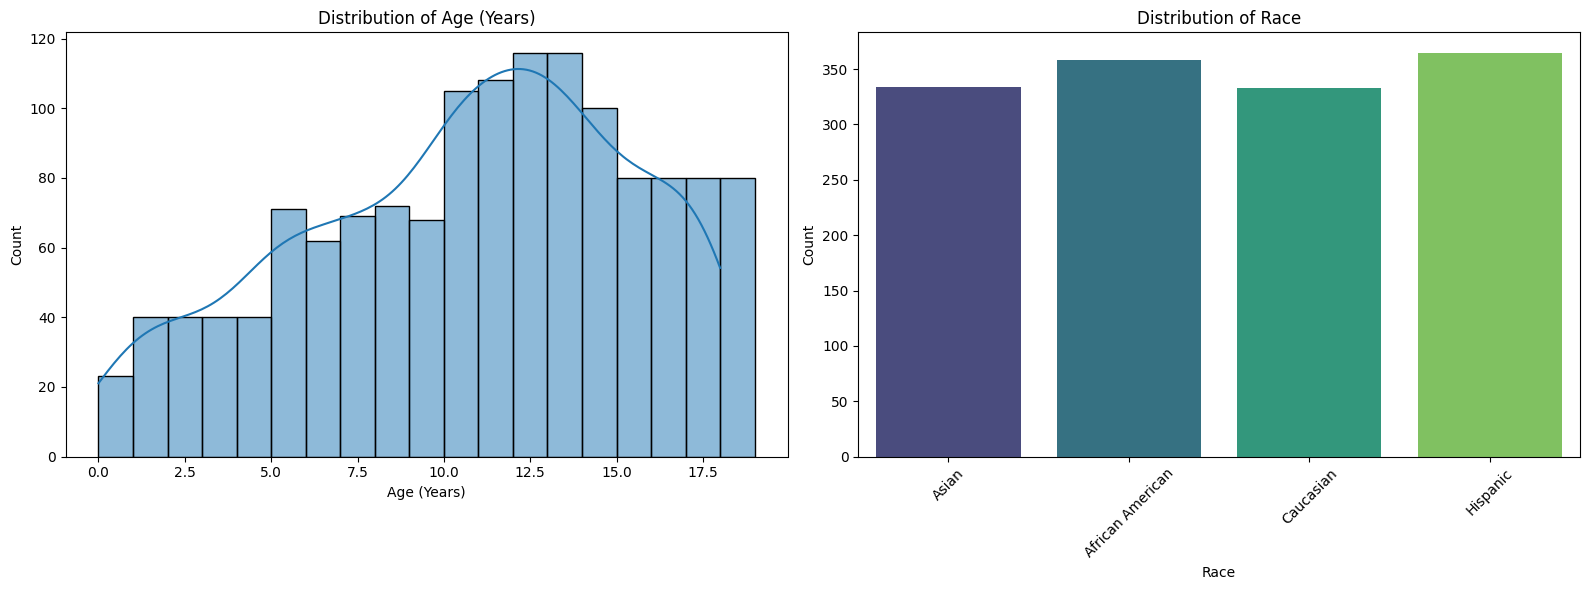

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histogram for 'age_years' distribution
sns.histplot(df['age_years'], bins=range(0, int(df['age_years'].max()) + 2, 1), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age (Years)')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')

# Plot 2: Bar chart for 'race' distribution
sns.countplot(data=df, x='race', ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Race')
axes[1].set_xlabel('Race')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Ensure proper spacing between subplots
plt.tight_layout()

# Display the plots
plt.show()

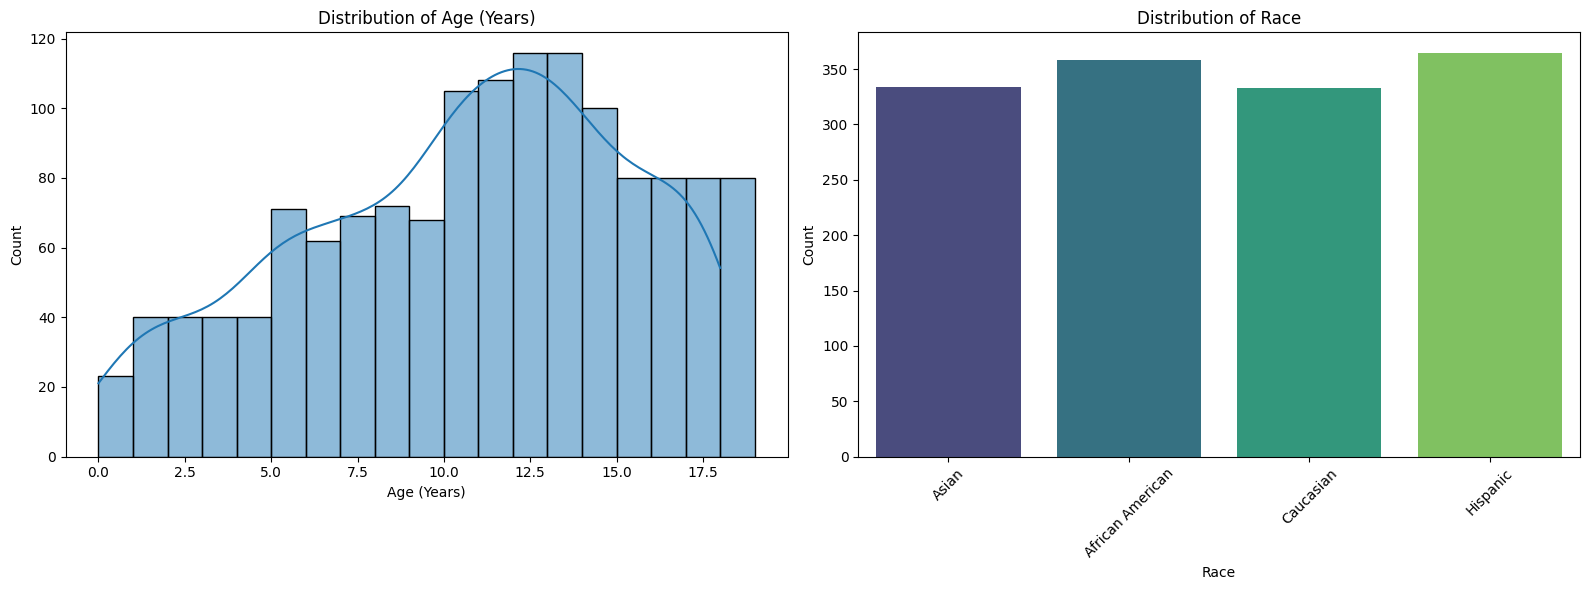

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histogram for 'age_years' distribution
sns.histplot(df['age_years'], bins=range(0, int(df['age_years'].max()) + 2, 1), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age (Years)')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')

# Plot 2: Bar chart for 'race' distribution
sns.countplot(data=df, x='race', hue='race', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Distribution of Race')
axes[1].set_xlabel('Race')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Ensure proper spacing between subplots
plt.tight_layout()

# Display the plots
plt.show()

## Visualize Age Distribution per Race




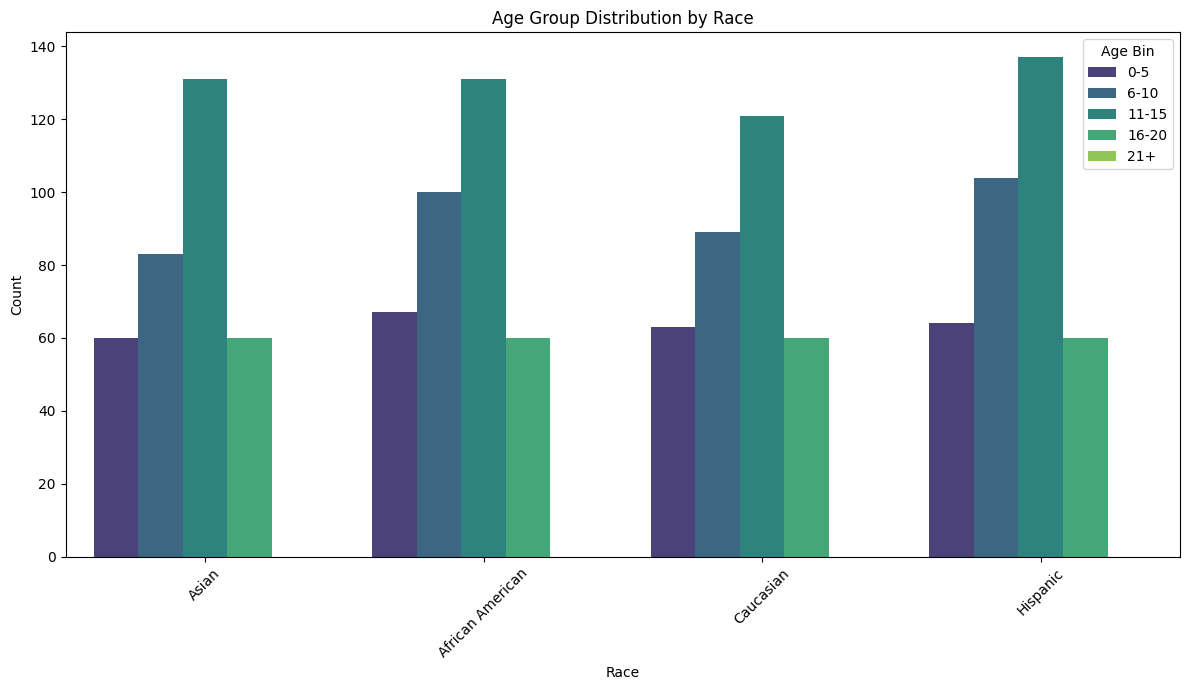

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='race', hue='age_bin', palette='viridis')
plt.title('Age Group Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45) # Rotate x-axis labels for readability
plt.legend(title='Age Bin')
plt.tight_layout()
plt.show()

## Zusammenfassung, Datensatzanalyse  ##
Wichtigste Ergebnisse der Datenanalyse*   Der Datensatz umfasst insgesamt 1390 Bilder.*   Die Verteilung der ethnischen Zugehörigkeit (Rasse) im Datensatz ist relativ ausgewogen: Hispanics (26,26 %), Afroamerikaner (25,76 %), Asiaten (24,03 %) und Kaukasier (23,96 %).*   Die Altersverteilung konzentriert sich auf jüngere Altersgruppen:*   `0–5` Jahre: 254 Bilder*   `6–10` Jahre: 376 Bilder*   `11–15` Jahre: 520 Bilder (die größte Gruppe)* `16–20` Jahre: 240 Bilder* Entscheidend ist, dass es in der Altersgruppe `21+` **0 Bilder** gibt, was darauf hindeutet, dass der Datensatz ausschliesslich Personen im Alter von 0 bis 20 Jahren enthält.* Visualisierungen (Histogramme, Balkendiagramme und gruppierte Balkendiagramme) bestätigen diese Verteilungen und zeigen ein konsistentes Muster der Altersverteilung über alle ethnischen Kategorien hinweg, was die Abwesenheit von Personen über 20 Jahren unterstreicht.* Das System kann Beispielbilder mit den entsprechenden Metadaten zu Alter und ethnischer Zugehörigkeit erfolgreich laden und anzeigen, sodass die Datenqualität visuell überprüft werden kann. *Erkenntnisse* Der Datensatz eignet sich aufgrund seiner ausgewogenen ethnischen Verteilung und klaren Altersgruppen für das Training von Modellen, die sich auf die Vorhersage von Alter und ethnischer Zugehörigkeit für die Altersgruppe 0–20 konzentrieren. Die Anwendbarkeit des Modells ist jedoch aufgrund des vollständigen Fehlens älterer Personen auf diesen spezifischen Altersbereich beschränkt.


## Initial Setup and Data Loading



In [ ]:
import os

# 1. Define ROOT and DATA_DIR
ROOT = BASE  # Use the already defined BASE as ROOT
DATA_DIR = os.path.join(ROOT, 'Data')

# 2. Ensure DATA_DIR exists
os.makedirs(DATA_DIR, exist_ok=True)
print(f"DATA_DIR: {DATA_DIR} (created if not exists)")

# 3. Identify and count rows with non-existent abs_path
before_filtering_len = len(df)
missing_files_indices = df[~df['abs_path'].apply(os.path.exists)].index
num_removed_rows = len(missing_files_indices)

# 4. Remove these rows from the DataFrame
df.drop(missing_files_indices, inplace=True)

# 5. Print the total number of rows removed
print(f"\nTotal rows removed due to missing image files: {num_removed_rows}")

# 6. Display the first few rows of the cleaned DataFrame and its new length
print(f"Remaining rows in DataFrame: {len(df)}")
print("\nFirst 5 rows of cleaned DataFrame:")
print(df.head())

DATA_DIR: /content/drive/MyDrive/Data (created if not exists)

Total rows removed due to missing image files: 1
Remaining rows in DataFrame: 1389

First 5 rows of cleaned DataFrame:
   age_years sex   race  dim0  dim1  dim2  min.  max.  \
0          0   F  Asian   928  1218     1  2163  4050   
1          1   F  Asian  1130  1500     1  1243  3665   
2          1   F  Asian  1153  1425     1  1612  3419   
3          1   F  Asian   960  1296     1  1524  3675   
4          1   F  Asian  1168  1434     1  1406  3616   

                                          image_path  \
0  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
1  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
2  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
3  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   
4  /media/yannick/Y-ext/Digital Hand Atlas/DICOM/...   

                                            abs_path age_bin  
0  /content/drive/MyDrive/DigitalHandAtlas/Digita...     0-5  
1  /content/

## Age Binning and Strata Creation

### Subtask:
Create an `age_bin` column based on the specified age ranges: [0,2), [2,5), [5,10), [10,13), [13,16), [16,19). Subsequently, create a `strata` column by concatenating `race` and `age_bin` for stratified splitting.


**Reasoning**:
The subtask requires creating an `age_bin` column with specific ranges and labels, then concatenating it with the `race` column to form a `strata` column, and finally displaying the distribution of the `strata` column. This code block will perform all these operations.



In [ ]:
import numpy as np

# 1. Define the age bins and corresponding labels
bins = [0, 2, 5, 10, 13, 16, 19, np.inf]
labels = ['0-1', '2-4', '5-9', '10-12', '13-15', '16-18', '19+']

# 2. Use pd.cut() to categorize the age_years column into these defined bins
df['age_bin'] = pd.cut(df['age_years'], bins=bins, labels=labels, right=False, include_lowest=True)

# 3. Create a new column named `strata` by concatenating `race` and `age_bin`
df['strata'] = df['race'].astype(str) + '_' + df['age_bin'].astype(str)

# 4. Display the value counts of the newly created strata column
print("Distribution of strata:")
print(df['strata'].value_counts().sort_index())

Distribution of strata:
strata
African American_0-1      19
African American_10-12    81
African American_13-15    76
African American_16-18    60
African American_2-4      30
African American_5-9      91
Asian_0-1                 13
Asian_10-12               85
Asian_13-15               75
Asian_16-18               60
Asian_2-4                 30
Asian_5-9                 71
Caucasian_0-1             16
Caucasian_10-12           77
Caucasian_13-15           67
Caucasian_16-18           60
Caucasian_2-4             30
Caucasian_5-9             83
Hispanic_0-1              15
Hispanic_10-12            85
Hispanic_13-15            78
Hispanic_16-18            60
Hispanic_2-4              30
Hispanic_5-9              97
Name: count, dtype: int64


## Data Splitting (Train, Validation, Test)



In [ ]:
from sklearn.model_selection import train_test_split
import os

# 2. Set a fixed random_state to 42 for reproducibility
RANDOM_STATE = 42

# 3. Check strata counts and determine stratify_col
strata_counts = df['strata'].value_counts()
if (strata_counts < 3).any():
    print("Warning: Some strata have fewer than 3 examples. Adjusting stratification to 'race'.")
    stratify_col = 'race'
else:
    stratify_col = 'strata'
print(f"Stratification will be done using the '{stratify_col}' column.")

# 4. Perform the first stratified split: df_train (64%) and df_rest (36%)
df_train, df_rest = train_test_split(
    df,
    test_size=0.36, # 36% for rest (validation + test)
    random_state=RANDOM_STATE,
    stratify=df[stratify_col]
)
print(f"Train set size: {len(df_train)}")
print(f"Rest set size: {len(df_rest)}")

# 5. Perform the second stratified split: df_val (16% of original) and df_test (20% of original)
# Calculate test_size relative to df_rest
# Original percentages: Train 64%, Val 16%, Test 20%
# df_rest is 36% of original. Val is 16/36, Test is 20/36 of df_rest
val_size_relative_to_rest = 0.16 / 0.36 # 16% of original / 36% of original

df_val, df_test = train_test_split(
    df_rest,
    test_size=(0.20 / 0.36), # 20% of original / 36% of original
    random_state=RANDOM_STATE,
    stratify=df_rest[stratify_col]
)
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")

# 6. Create a directory named 'splits' inside DATA_DIR if it doesn't already exist.
SPLITS_DIR = os.path.join(DATA_DIR, 'splits')
os.makedirs(SPLITS_DIR, exist_ok=True)
print(f"Splits directory created at: {SPLITS_DIR}")

# 7. Save the resulting DataFrames to CSV files
output_columns = ['abs_path', 'age_years', 'race', 'age_bin']

df_train[output_columns].to_csv(os.path.join(SPLITS_DIR, 'train.csv'), index=False)
df_val[output_columns].to_csv(os.path.join(SPLITS_DIR, 'validation.csv'), index=False)
df_test[output_columns].to_csv(os.path.join(SPLITS_DIR, 'test.csv'), index=False)

print("Train, validation, and test sets saved to CSV files.")

Stratification will be done using the 'strata' column.
Train set size: 888
Rest set size: 501
Validation set size: 222
Test set size: 279
Splits directory created at: /content/drive/MyDrive/Data/splits
Train, validation, and test sets saved to CSV files.


In [ ]:
import pandas as pd
import os

# Helper function to generate report for a DataFrame
def generate_split_report(df_name, df, race_dists, age_bin_dists):
    print(f"\n--- {df_name.upper()} SPLIT REPORT ---")

    # 1a. Total number of images
    total_images = len(df)
    print(f"Total number of images: {total_images}")

    # 1b. Percentage distribution of 'race'
    race_distribution = df['race'].value_counts(normalize=True) * 100
    race_dists[df_name] = race_distribution
    print(f"\nPercentage Distribution of 'race':\n{race_distribution.round(2).to_string()}")

    # 1c. Percentage distribution of 'age_bin'
    age_bin_distribution = df['age_bin'].value_counts(normalize=True) * 100
    age_bin_dists[df_name] = age_bin_distribution
    print(f"\nPercentage Distribution of 'age_bin':\n{age_bin_distribution.round(2).to_string()}")

    # 1d. Cross-tabulation of 'race' by 'age_bin' in percentages
    cross_tab = pd.crosstab(df['race'], df['age_bin'], normalize='all') * 100
    print(f"\nCross-tabulation (race by age_bin) in percentages:\n{cross_tab.round(2).to_string()}")


# Load the DataFrames
df_train_report = pd.read_csv(os.path.join(SPLITS_DIR, 'train.csv'))
df_val_report = pd.read_csv(os.path.join(SPLITS_DIR, 'validation.csv'))
df_test_report = pd.read_csv(os.path.join(SPLITS_DIR, 'test.csv'))

# Dictionaries to store distributions for comparison
race_distributions = {}
age_bin_distributions = {}

# Generate reports for each split
generate_split_report('train', df_train_report, race_distributions, age_bin_distributions)
generate_split_report('validation', df_val_report, race_distributions, age_bin_distributions)
generate_split_report('test', df_test_report, race_distributions, age_bin_distributions)


# --- Comparison Logic ---

def compare_distributions(dist1_name, dist1, dist2_name, dist2, col_name):
    deviations = []
    all_categories = pd.concat([dist1, dist2]).index.unique()

    for category in all_categories:
        val1 = dist1.get(category, 0.0)
        val2 = dist2.get(category, 0.0)
        diff = abs(val1 - val2)

        if diff > 2.0:
            deviations.append(f"  - Category '{category}': {dist1_name} {val1:.2f}% vs {dist2_name} {val2:.2f}% (Deviation: {diff:.2f} percentage points)")
    return deviations

print("\n--- DEVIATION CHECK (Max 2 percentage points allowed) ---")

split_names = ['train', 'validation', 'test']
split_dfs = {
    'train': df_train_report,
    'validation': df_val_report,
    'test': df_test_report
}

# Compare Race Distributions
print("\nComparing 'race' distributions across splits:")
for i in range(len(split_names)):
    for j in range(i + 1, len(split_names)):
        name1, name2 = split_names[i], split_names[j]
        deviations = compare_distributions(name1, race_distributions[name1], name2, race_distributions[name2], 'race')
        if deviations:
            print(f"Deviations between {name1} and {name2} for 'race':")
            for dev in deviations:
                print(dev)
        else:
            print(f"No significant deviations between {name1} and {name2} for 'race'.")

# Compare Age Bin Distributions
print("\nComparing 'age_bin' distributions across splits:")
for i in range(len(split_names)):
    for j in range(i + 1, len(split_names)):
        name1, name2 = split_names[i], split_names[j]
        deviations = compare_distributions(name1, age_bin_distributions[name1], name2, age_bin_distributions[name2], 'age_bin')
        if deviations:
            print(f"Deviations between {name1} and {name2} for 'age_bin':")
            for dev in deviations:
                print(dev)
        else:
            print(f"No significant deviations between {name1} and {name2} for 'age_bin'.")



--- TRAIN SPLIT REPORT ---
Total number of images: 888

Percentage Distribution of 'race':
race
Hispanic            26.35
African American    25.68
Asian               24.10
Caucasian           23.87

Percentage Distribution of 'age_bin':
age_bin
5-9      24.66
10-12    23.54
13-15    21.40
16-18    17.34
2-4       8.56
0-1       4.50

Cross-tabulation (race by age_bin) in percentages:
age_bin            0-1  10-12  13-15  16-18   2-4   5-9
race                                                   
African American  1.35   5.86   5.52   4.28  2.14  6.53
Asian             0.90   6.08   5.41   4.39  2.14  5.18
Caucasian         1.13   5.52   4.84   4.28  2.14  5.97
Hispanic          1.13   6.08   5.63   4.39  2.14  6.98

--- VALIDATION SPLIT REPORT ---
Total number of images: 222

Percentage Distribution of 'race':
race
African American    26.13
Hispanic            25.68
Caucasian           24.32
Asian               23.87

Percentage Distribution of 'age_bin':
age_bin
5-9      24.32
10-12 

## Summary:

### Data Analysis Key Findings

*   **Data Cleaning**: During initial setup, 1 row was removed from the dataset due to a missing image file, resulting in a cleaned DataFrame of 1389 entries.
*   **Age Binning**: An `age_bin` column was created using specified age ranges: `[0-1, 2-4, 5-9, 10-12, 13-15, 16-18, 19+]`.
*   **Stratification Strategy**: A `strata` column was created by combining `race` and `age_bin`. This `strata` column was successfully used for splitting, as no individual stratum had fewer than 3 examples.
*   **Data Split Sizes**:
    *   Train set: 888 images (approximately 64% of the total).
    *   Validation set: 222 images (approximately 16% of the total).
    *   Test set: 279 images (approximately 20% of the total).
*   **Split File Locations**: The `train.csv`, `validation.csv`, and `test.csv` files, containing `abs_path`, `age_years`, `race`, and `age_bin` columns, were saved to `/content/drive/MyDrive/Data/splits/`.
*   **Distribution Consistency**: Post-split analysis confirmed no significant deviations (greater than 2 percentage points) in the distribution of 'race' or 'age_bin' categories between the train, validation, and test datasets, indicating a successful stratified split.



Wir splitten stratifiziert nach Ethnie und Alters-Bins, weil beide Merkmale die Vorhersagen beeinflussen. So bleiben die Anteile in Train, Val, Test ähnlich.
• 64, 16, 20 balanciert Lernmenge und sauberen Holdout. Val steuert Modellwahl und Hyperparameter. Test bleibt unangetastet bis zum Schluss.

• Kleine Untergruppen führen sonst zu leeren Klassen in Val oder Test. Falls eine Gruppe zu klein war (< 3 Beispiele), wurde als Fallback nur nach Ethnie stratifiziert.
• Wir belegen die Fairness mit Verteilungs-Tabellen und drucken Abweichungen in Prozentpunkten.

**Begründete Wahl von Analysemetriken (Genauigkeit, Sensitivität, etc.). Ist zum Beispiel eine hohe Sensitivität oder Spezifizität erstrebenswert?**

Ziele
schätzt das Alter aus Röntgenbildern und ordnest parallel eine Ethnie zu. genaue Vorhersagen und faire Ergebnisse über alle Gruppen.

Alter, Regression
• MAE. Durchschnittlicher Fehler in Jahren. Direkt verständlich. Hauptmetrik.
• RMSE. Bestraft große Ausreißer stärker. Nebenmetrik.
• P2.0. Anteil der Fälle mit Fehler bis 2 Jahre. Optional, gut für Praxisnähe.

Begründung
MAE zeigt sofort, wie weit im Mittel daneben. RMSE sorgt dafür, grosse Fehlgriffe nicht zu übersehen. P2.0 verbindet das Ziel mit einer klaren Toleranz.

Ethnie, Klassifikation
• Accuracy. Gesamtanteil richtig. Referenzwert.
• Balanced Accuracy. Mittlerer Rückruf über Klassen. Fair bei ungleichen Anteilen.
• F1 macro. Gleichgewicht aus Präzision und Rückruf pro Klasse, danach gemittelt. Hauptmetrik.
• Per-Klasse-Werte und Confusion Matrix. Für Bias-Check und Fehleranalyse.

Begründung
Accuracy wirkt gut, verschleiert aber Schieflagen. F1 macro gibt allen Klassen gleich Gewicht. Balanced Accuracy misst, ob du jede Klasse ähnlich gut findest. Per-Klasse-Werte zeigen, wo es hakt.




Wir bewerten mit MAE als Hauptmetrik, ergänzt durch RMSE und den Anteil der Vorhersagen innerhalb von 2 Jahren. Für die Ethnie verwenden wir F1 macro als Hauptmetrik, ergänzt durch Balanced Accuracy und Accuracy. Diese Wahl stellt Ausgeglichenheit über alle Klassen sicher und bestraft große Fehler. Zusätzlich berichten wir Precision und Recall je Klasse sowie eine Confusion Matrix, um mögliche Schieflagen früh zu erkennen.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Definierte Transforms ---
Training Transforms:
Compose([
  Affine(p=0.5, balanced_scale=False, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(0.0, 3.0), rotate_method='largest_box', scale={'x': (0.95, 1.05), 'y': (0.95, 1.05)}, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, translate_percent={'x': (0.05, 0.05), 'y': (0.05, 0.05)}, translate_px=None),
  ColorJitter(p=1.0, brightness=(0.9, 1.1), contrast=(0.9, 1.1), hue=(-0.5, 0.5), saturation=(0.8, 1.2)),
  Resize(p=1.0, area_for_downscale=None, height=384, interpolation=1, mask_interpolation=0, width=384),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.5, 0.5, 0.5), normalization='standard', std=(0.25, 0.25, 0.25)),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

Validation/Test Transf

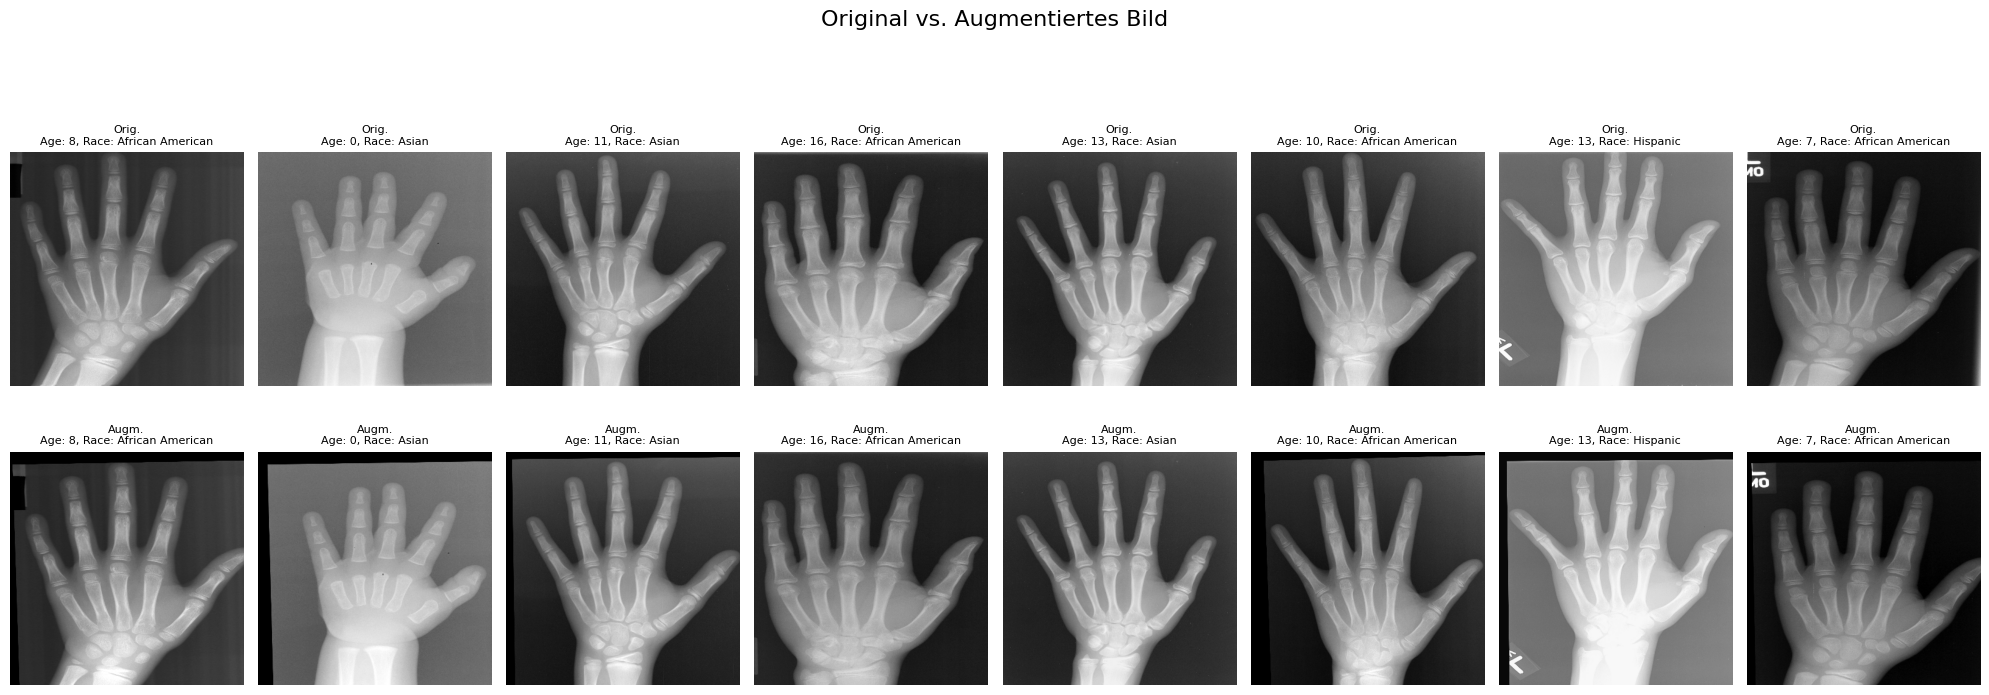

In [ ]:
import torch
# import torchvision.transforms as transforms # Removed as Albumentations is used
import pandas as pd
import matplotlib.pyplot as plt
# from PIL import Image # Removed as OpenCV is used for image loading
import os
from google.colab import drive

# 1. Google Drive mounten
drive.mount('/content/drive')

# Install albumentations and opencv-python-headless
# opencv-python-headless is preferred for server environments without a GUI
!pip install -U albumentations opencv-python-headless

# Update imports to use albumentations and cv2
import albumentations as A
import cv2
import numpy as np # Needed for denormalization

# 2. Pfade setzen
# BITTE DIESE ZEILEN BEI BEDARF ANPASSEN:
# IMAGES_DIR sollte der Ordner sein, der die Bilder enthält.
# CSV_PATH sollte der Pfad zur CSV-Datei sein.
IMAGES_DIR = '/content/drive/MyDrive/DigitalHandAtlas' # Entspricht IMG_ROOT aus vorherigen Zellen
CSV_PATH = '/content/drive/MyDrive/datastats.csv'     # Entspricht CSV_PATH aus vorherigen Zellen

# Normalisierungsparameter
NORM_MEAN = [0.5, 0.5, 0.5] # Mittelwerte für RGB-Kanäle (0-1 Bereich)
NORM_STD = [0.25, 0.25, 0.25] # Standardabweichungen für RGB-Kanäle (0-1 Bereich)

# Convert to numpy arrays for easier denormalization later
NORM_MEAN_NP = np.array(NORM_MEAN)
NORM_STD_NP = np.array(NORM_STD)

# 3. Augmentationen definieren mit Albumentations

# Transforms für Trainingsdaten (mit Augmentationen)
train_transforms = A.Compose([
    # Affine transformation (Rotation, Scale, Translate)
    A.Affine(scale=(0.95, 1.05), translate_percent=(0.05, 0.05), rotate=(0, 3), p=0.5, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_CONSTANT),
    # Color Jitter
    A.ColorJitter(brightness=0.1, contrast=0.1, p=1),
    # Resize to a uniform size
    A.Resize(height=384, width=384, interpolation=cv2.INTER_LINEAR, p=1),
    # Normalize pixel values
    # max_pixel_value=255.0 because cv2.imread loads 0-255 uint8 images
    A.Normalize(mean=NORM_MEAN, std=NORM_STD, max_pixel_value=255.0, p=1)
])

# Transforms für Validierungs- und Testdaten (nur Resize und Normalisierung)
val_test_transforms = A.Compose([
    A.Resize(height=384, width=384, interpolation=cv2.INTER_LINEAR, p=1),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD, max_pixel_value=255.0, p=1)
])

# 4. Die gewählten Transforms textlich ausgeben
print("--- Definierte Transforms ---")
print("Training Transforms:")
print(train_transforms)
print("\nValidation/Test Transforms:")
print(val_test_transforms)
print("-" * 30)

# 5. CSV laden und 8 zufällige Bilder auswählen
# Annahme: 'df' ist aus vorherigen Zellen verfügbar und enthält 'abs_path', 'age_years', 'race'.
# Falls nicht, muss die CSV neu geladen und die Spalten vorbereitet werden.
# The existing 'df' from previous cells is already cleaned and has 'abs_path'.
# The following block is a fallback in case the kernel state is reset and df is not defined.
if 'df' not in locals():
    try:
        df = pd.read_csv(CSV_PATH)
        df.columns = df.columns.str.strip().str.lower()
        df = df.rename(columns={'path': 'image_path', 'age': 'age_years'})
        if 'abs_path' not in df.columns:
            # This is a highly simplified fallback. The full logic for path resolution
            # and extension handling is in previous cells (fd655766).
            df['abs_path'] = df['image_path'].str.replace('/media/yannick/Y-ext/Digital Hand Atlas', IMAGES_DIR, regex=False)
            # Further robust path resolution would be needed here if 'abs_path' was not already correctly populated
            print("WARNUNG: 'abs_path' Spalte wurde in dieser Zelle vereinfacht erstellt. Bitte stellen Sie sicher, dass die vorherigen umfassenden Pfadbereinigungsschritte ausgeführt wurden.")

        # Filter for existing images, as done in previous steps
        df = df[df['abs_path'].apply(os.path.exists)]
        print(f"CSV-Datei erfolgreich geladen und 'df' mit {len(df)} Zeilen vorbereitet.")

    except FileNotFoundError:
        print(f"Fehler: CSV-Datei nicht gefunden unter {CSV_PATH}. Bitte stellen Sie sicher, dass der Pfad korrekt ist.")
        exit() # Terminate script if CSV cannot be loaded
    except Exception as e:
        print(f"Fehler beim Laden/Vorbereiten der CSV: {e}")
        exit()

# Filter again for existing files, just to be safe and to ensure the latest 'df' is used
df_filtered = df[df['abs_path'].apply(os.path.exists)]

if len(df_filtered) < 8:
    print(f"WARNUNG: Nur {len(df_filtered)} Bilder gefunden, weniger als 8. Zeige alle verfügbaren Bilder.")
    sample_df = df_filtered.sample(n=len(df_filtered), random_state=42).reset_index(drop=True)
else:
    sample_df = df_filtered.sample(n=8, random_state=42).reset_index(drop=True)

print(f"\n{len(sample_df)} zufällige Bilder zum Anzeigen ausgewählt.")

# 6. Bilder laden, augmentieren und anzeigen
num_samples = len(sample_df)
if num_samples > 0:
    fig, axes = plt.subplots(2, num_samples, figsize=(2.5 * num_samples, 8))
    fig.suptitle('Original vs. Augmentiertes Bild', fontsize=16)

    for i in range(num_samples):
        row = sample_df.iloc[i]
        image_path = row['abs_path']
        age = row['age_years']
        race = row['race']

        try:
            # Load image using OpenCV and convert BGR to RGB
            image_bgr = cv2.imread(image_path)
            if image_bgr is None:
                raise FileNotFoundError(f"OpenCV could not load image at {image_path}")
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB) # Albumentations expects RGB

            # Apply transforms using Albumentations
            # For 'original' display, use val_test_transforms (resize and normalize)
            transformed_original = val_test_transforms(image=image_rgb)['image']
            # For 'augmented' display, use train_transforms (with augmentations)
            transformed_augmented = train_transforms(image=image_rgb)['image']

            # Denormalize for display (Albumentations outputs normalized float32 NumPy arrays, HWC)
            # Reverse the normalization: pixel = (normalized_pixel * std) + mean
            original_img_display = transformed_original * NORM_STD_NP + NORM_MEAN_NP
            original_img_display = np.clip(original_img_display, 0, 1) # Clip to 0-1 range for imshow

            augmented_img_display = transformed_augmented * NORM_STD_NP + NORM_MEAN_NP
            augmented_img_display = np.clip(augmented_img_display, 0, 1) # Clip to 0-1 range for imshow

            # Original anzeigen
            # Adjust for cases where num_samples is 1 (axes is 1D or a single object)
            current_ax_orig = axes[0, i] if num_samples > 1 else axes[0]
            current_ax_orig.imshow(original_img_display)
            current_ax_orig.set_title(f"Orig.\nAge: {age}, Race: {race}", fontsize=8)
            current_ax_orig.axis('off')

            # Augmentiertes Bild anzeigen
            current_ax_aug = axes[1, i] if num_samples > 1 else axes[1]
            current_ax_aug.imshow(augmented_img_display)
            current_ax_aug.set_title(f"Augm.\nAge: {age}, Race: {race}", fontsize=8)
            current_ax_aug.axis('off')

        except (FileNotFoundError, Exception) as e:
            print(f"Warnung: Fehler beim Laden/Verarbeiten von Bild {image_path}: {e}. Überspringe und setze Subplots auf unsichtbar.")
            # Set the axes for this sample to invisible if an error occurs
            if num_samples > 1:
                if axes.size > 0 and i < axes.shape[1]: # Check bounds
                    axes[0, i].set_visible(False)
                    axes[1, i].set_visible(False)
            elif axes.size > 0: # Handle single image case
                axes[0].set_visible(False)
                axes[1].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
    plt.show()
else:
    print("Keine Bilder zum Anzeigen verfügbar nach Filterung oder keine ausreichende Anzahl.\nPlease check IMAGES_DIR, CSV_PATH, and the content of the CSV file.")


## Begründung
Kleine Rotation bis 3 Grad, um leichte Schieflagen abzudecken. Grosse Drehungen würden die Handlage verfälschen.

Shift und Scale bis 3 Prozent, um kleine Lage- und Zoomfehler zu simulieren.

Helligkeit und Kontrast ±0.15, um Geräte- und Belichtungsunterschiede abzudecken.

Leichtes Rauschen, um Sensorrauschen zu simulieren.

Kein Flip, es sind linke Hände. Ein Flip würde falsche Anatomie erzeugen.

Keine harten Verzerrungen, die Knochenform muss erhalten bleiben.

Realismus: Die affinen Transformationen simulieren typische Aufnahmefehler in der Praxis, wie leichte Schieflagen der Hand, unterschiedliche Abstände zum Röntgengerät oder nicht perfekt zentrierte Hände.
Hardware-Unterschiede: Helligkeits- und Kontrastschwankungen decken Unterschiede zwischen verschiedenen Röntgengeräten und Belichtungseinstellungen ab.
Jedoch sind die vorgegebenen Bilder bereits recht gut und  wie wir später sehen wäre noch weniger/keine Augmentation nötig gewesen.

Umsetzung im Code: Die Umsetzung erfolgt in den transforms.Compose (Torchvision) bzw. A.Compose (Albumentations) Pipelines für den Trainings-Datensatz:

    ResNet18 (Zelle UzEyXw1LPgun): Nutzung von transforms.RandomAffine (für Geometrie) und transforms.ColorJitter (für Licht).
    CustomCNN (Zelle ded382ed): Nutzung von A.Affine und A.ColorJitter.




**Wahl der Lossfunktion**

1. Für das Alter (Regression): nn.SmoothL1Loss

    Anwendung: Berechnet den Fehler zwischen dem vorhergesagten und dem echten Alter.
    Begründung: Diese Funktion (Huber-Loss ) ist ein Mittelweg aus L1 (MAE) und L2 (MSE). Sie ist robuster gegen Ausreisser als der quadratische Fehler (MSE), aber nahe bei Null stabiler zu optimieren als der absolute Fehler (MAE). Das ist ideal für Altersdaten, die meist stimmen, aber gelegentlich stark abweichen können.

2. Für die Ethnie (Klassifikation): nn.CrossEntropyLoss

    Anwendung: Berechnet, wie stark die vorhergesagten Wahrscheinlichkeiten von der echten Kategorie abweichen.
    Begründung: Dies ist der Standard für Multi-Klassen-Klassifikation. Wichtig war hier der Parameter weight=class_weights, der Klassengewichte nutzt. Da die ethnischen Gruppen nicht perfekt gleich verteilt sind, sorgt dies dafür, dass Fehler bei selteneren Gruppen stärker bestraft werden, damit das Modell diese nicht ignoriert (Fairness)

Grundaufbau des Netzes

Das Modell besteht aus drei Teilen:

Gemeinsamer Feature-Extractor (Backbone)

Kopf für die Altersschätzung (Regression)

Kopf für die Ethnizitätsvorhersage (Klassifikation)

Der gemeinsame Teil verarbeitet das Bild und erzeugt eine Merkmalsdarstellung, die beiden Köpfen zur Verfügung steht. So nutzt das Modell dieselben Bildinformationen sowohl für Alter als auch für Ethnizität.

Feature-Extractor im Detail

Der Backbone ist in vier Stufen aufgebaut:

– Stem: Erste Schicht mit 32 Filtern, gefolgt von Batch-Normalisierung, ReLU und MaxPooling. Hier werden einfache Kanten und Strukturen aus dem Röntgenbild extrahiert und die Auflösung halbiert.
– Block1: Erhöht die Kanalzahl auf 64, wieder mit Conv, BatchNorm, ReLU und MaxPooling. Das Bild wird kleiner, die Merkmale werden komplexer.
– Block2: Gleiches Prinzip, jetzt 128 Kanäle. Hier lernt das Netz bereits typische Muster von Handknochen und Wachstumszonen.
– Block3: Das ist der „aufwendigste“ Block. Er besteht aus zwei sogenannten Separable-Convolutions (erst kanalweise, dann 1x1 Mischung) plus einem SE-Block und einer Residual-Verbindung.

Warum diese Entscheidungen:

– SeparableConv: Diese Schichten sind recheneffizient. Sie reduzieren die Anzahl der Parameter, weil sie zuerst pro Kanal filtern und dann Kanäle mischen. Für unseren begrenzten Datensatz ist ein kleineres Modell sinnvoll, um Overfitting zu vermeiden und Colab-Ressourcen zu schonen.
– SEBlock: Der SE-Block lernt, welche Kanäle wichtig sind. Er „gewichtet“ die Merkmale, die für die Aufgabe relevanter sind. Bei Handröntgenbildern ist nicht alles im Bild gleich wichtig.
– Residual-Projektion: Wir addieren die Ausgabe von Block3 zu einer projizierten Version des Inputs (1x1-Conv). Das stabilisiert das Training, weil Informationen aus früheren Schichten direkt weitergegeben werden. Dieses Prinzip ist aus ResNet übernommen, aber in einer einfacheren Form.

Am Ende des Feature-Teils setzen wir eine globale Durchschnittspoolung ein. Sie reduziert die räumlichen Dimensionen auf einen 128-dimensionalen Feature-Vektor pro Bild. Das ist robust und deutlich einfacher als mehrere voll verbundene Schichten auf einem großen Feature-Map.

Zwei Köpfe für zwei Aufgaben

Aus dem gemeinsamen Feature-Vektor verzweigen zwei Köpfe:

– Age-Head:
– Linear 128 → 64, ReLU, Dropout
– Linear 64 → 1
Dieser Kopf gibt ein reelles Alter zurück. Dropout dient hier als Regularisierung, damit das Modell nicht nur Spezialfälle auswendig lernt.

– Ethnicity-Head:
– Linear 128 → 64, ReLU, Dropout
– Linear 64 → num_eth_classes
Dieser Kopf gibt für jede Ethnie eine Logit-Ausgabe, die in der Loss-Funktion zu Wahrscheinlichkeiten wird.

Warum dieser Aufbau:

– Gemeinsame Features sind sinnvoll, weil sowohl Alter als auch Ethnizität auf den gleichen Knochenstrukturen basieren.
– Die Köpfe sind bewusst klein gehalten, um Overfitting zu reduzieren. Mehr Schichten würden bei unserem Datensatz kaum Mehrwert bringen, aber das Risiko erhöhen, dass das Modell die Trainingsbilder „auswendig lernt“.

Training und Design-Entscheidungen

Zum Training des Custom-CNN haben wir zusätzlich folgende Designpunkte umgesetzt:

– Bildgrösse 384x384, gleiche Normalisierung wie beim ResNet18. So ist der Vergleich fair.
– WeightedRandomSampler und Klassen-Gewichte in der CrossEntropyLoss. So werden seltener vorkommende Ethnien im Training stärker berücksichtigt.
– Gemeinsamer Loss: 0.4 für das Alter, 0.6 für Ethnizität. Begründung: Die Klassifikation ist die schwierigere Aufgabe, deshalb haben wir sie leicht höher gewichtet, ohne die Altersschätzung zu vernachlässigen.
– Label-Smoothing beim Ethnizitäts-Loss, um zu harte Entscheidungen und Overfitting zu vermeiden.

Using device: cuda
DataFrames loaded successfully.
Ethnicity classes: ['African American' 'Asian' 'Caucasian' 'Hispanic']
CustomCNN class defined successfully.
DataLoaders created. Train batches: 28
Starting training...


/tmp/ipython-input-3879859502.py:229: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


Epoch 1/20:   0%|          | 0/28 [00:00<?, ?it/s]

/tmp/ipython-input-3879859502.py:251: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 1: Train Loss: 4.3410 | Val Loss: 4.4271 | Val MAE: 9.4730 | Val F1: 0.1634
>>> Model Saved (New Best F1: 0.1634)


...

Epoch 20/20:   0%|          | 0/28 [00:00<?, ?it/s]

/tmp/ipython-input-3879859502.py:251: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 20: Train Loss: 1.7825 | Val Loss: 1.8233 | Val MAE: 3.0376 | Val F1: 0.2731

Loading best model for evaluation...


Testing:   0%|          | 0/9 [00:00<?, ?it/s]


--- Test Set Results ---
Age MAE: 4.5850
Age RMSE: 5.3777
Ethnicity Accuracy: 0.2867
Ethnicity Balanced Acc: 0.2939
Ethnicity F1-Macro: 0.2357


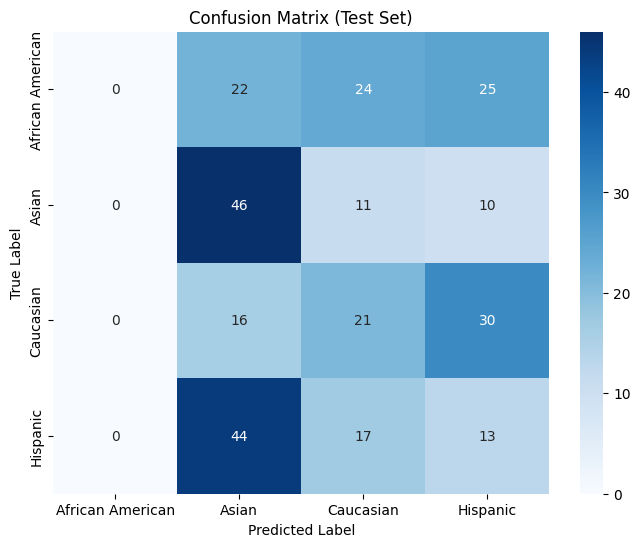

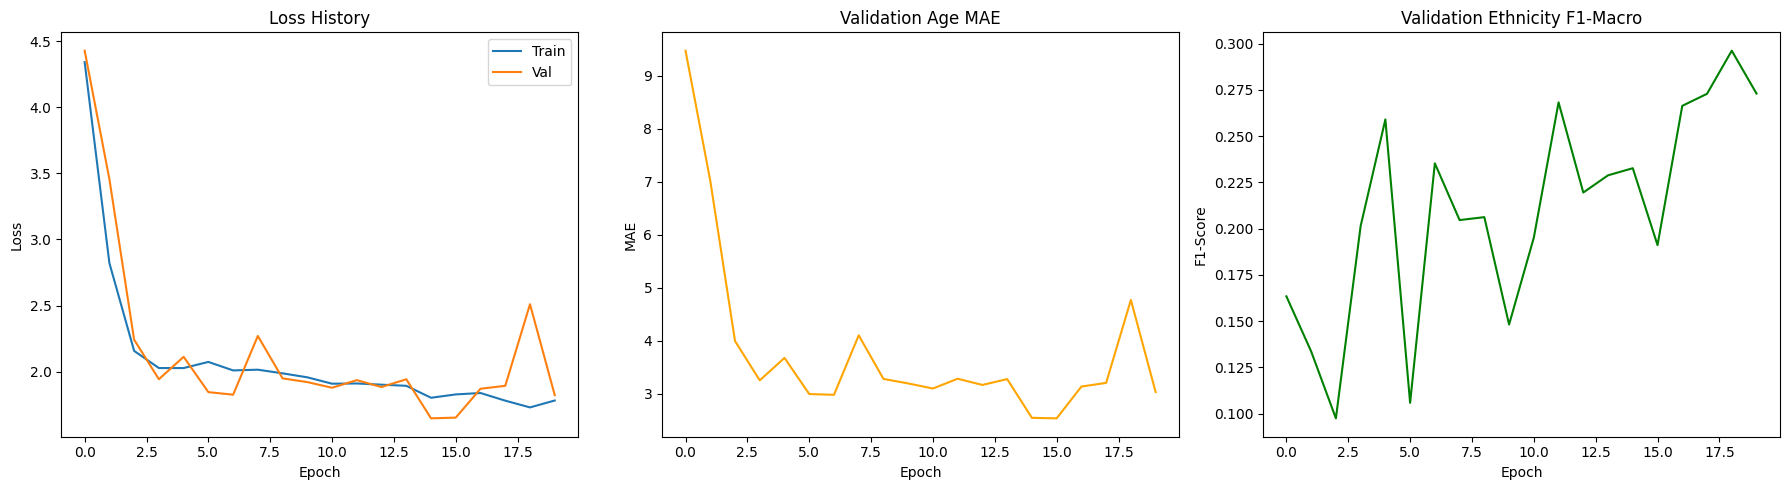

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch.nn.functional as F

# Configuration
BATCH_SIZE = 32
LR = 3e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = '/content/best_custom_model.pt'
SPLITS_DIR = '/content/drive/MyDrive/Data/splits'

print(f"Using device: {DEVICE}")

# --- 0. Load Data and Preprocess ---
try:
    df_train = pd.read_csv(os.path.join(SPLITS_DIR, 'train.csv'))
    df_val = pd.read_csv(os.path.join(SPLITS_DIR, 'validation.csv'))
    df_test = pd.read_csv(os.path.join(SPLITS_DIR, 'test.csv'))
    print("DataFrames loaded successfully.")
except FileNotFoundError:
    print(f"Error: Could not find split files in {SPLITS_DIR}. Please check the path.")
    raise

# Encode Race
le = LabelEncoder()
# Fit on all available race labels to ensure consistency
all_races = pd.concat([df_train['race'], df_val['race'], df_test['race']]).unique()
le.fit(all_races)

df_train['race_encoded'] = le.transform(df_train['race'])
df_val['race_encoded'] = le.transform(df_val['race'])
df_test['race_encoded'] = le.transform(df_test['race'])

num_eth_classes = len(le.classes_)
print(f"Ethnicity classes: {le.classes_}")

# --- 1. Define Model Architecture ---

class SeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=False):
        super(SeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                   stride=stride, padding=padding, groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class CustomCNN(nn.Module):
    def __init__(self, num_eth_classes):
        super(CustomCNN, self).__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block1
        self.block1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block3
        self.block3_conv1 = nn.Sequential(
            SeparableConv(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.block3_conv2 = nn.Sequential(
            SeparableConv(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.block3_se = SEBlock(128)

        self.residual_proj = nn.Conv2d(128, 128, kernel_size=1)

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.age_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

        self.eth_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_eth_classes)
        )

    def forward(self, x):
        x_stem = self.stem(x)
        x_block1 = self.block1(x_stem)
        x_block2 = self.block2(x_block1)

        residual = self.residual_proj(x_block2)
        x_block3 = self.block3_conv1(x_block2)
        x_block3 = self.block3_conv2(x_block3)
        x_block3 = self.block3_se(x_block3)
        x_block3 = x_block3 + residual

        features = self.global_avg_pool(x_block3).flatten(1)

        age_pred = self.age_head(features)
        eth_pred = self.eth_head(features)

        return age_pred, eth_pred

print("CustomCNN class defined successfully.")

# --- 2. Data Loading and Augmentation ---
NORM_MEAN = [0.5, 0.5, 0.5]
NORM_STD = [0.25, 0.25, 0.25]

train_transforms = A.Compose([
    A.Resize(384, 384),
    A.Affine(scale=(0.95, 1.05), translate_percent=(0.05, 0.05), rotate=(-3, 3), p=0.5,
             interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_CONSTANT),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

val_test_transforms = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

class RealImageDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['abs_path']
        image = cv2.imread(path)
        if image is None:
            image = np.zeros((384, 384, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented['image']

        age = torch.tensor(row['age_years'], dtype=torch.float32)
        eth = torch.tensor(row['race_encoded'], dtype=torch.long)
        return image, age, eth

train_dataset = RealImageDataset(df_train, train_transforms)
val_dataset = RealImageDataset(df_val, val_test_transforms)
test_dataset = RealImageDataset(df_test, val_test_transforms)

# --- 3. Sampling and DataLoaders ---
class_counts = df_train['race_encoded'].value_counts().sort_index()
weights = 1.0 / class_counts
sample_weights = df_train['race_encoded'].map(weights).values
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Set num_workers to 0 to avoid multiprocessing errors in Colab
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created. Train batches: {len(train_loader)}")

# --- 4. Model and Optimization Setup ---
model = CustomCNN(num_eth_classes=num_eth_classes).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

cw = class_weight.compute_class_weight('balanced', classes=np.unique(df_train['race_encoded']), y=df_train['race_encoded'])
class_weights_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

criterion_age = nn.SmoothL1Loss()
criterion_eth = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

# --- 5. Training Loop ---
best_val_f1 = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_f1': []}

print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for imgs, ages, eths in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, ages, eths = imgs.to(DEVICE), ages.to(DEVICE), eths.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            pred_age, pred_eth = model(imgs)
            loss_age = criterion_age(pred_age.squeeze(), ages)
            loss_eth = criterion_eth(pred_eth, eths)
            loss = 0.4 * loss_age + 0.6 * loss_eth

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_train_loss)

    model.eval()
    val_loss = 0.0
    val_ages_true, val_ages_pred = [], []
    val_eths_true, val_eths_pred = [], []

    with torch.no_grad():
        for imgs, ages, eths in val_loader:
            imgs, ages, eths = imgs.to(DEVICE), ages.to(DEVICE), eths.to(DEVICE)

            pred_age, pred_eth = model(imgs)
            l_age = criterion_age(pred_age.squeeze(), ages)
            l_eth = criterion_eth(pred_eth, eths)
            loss = 0.4 * l_age + 0.6 * l_eth
            val_loss += loss.item()

            val_ages_true.extend(ages.cpu().numpy())
            val_ages_pred.extend(pred_age.squeeze().cpu().numpy())
            val_eths_true.extend(eths.cpu().numpy())
            val_eths_pred.extend(torch.argmax(pred_eth, dim=1).cpu().numpy())

    epoch_val_loss = val_loss / len(val_loader)
    val_mae = mean_absolute_error(val_ages_true, val_ages_pred)
    val_f1 = f1_score(val_eths_true, val_eths_pred, average='macro')

    history['val_loss'].append(epoch_val_loss)
    history['val_mae'].append(val_mae)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val MAE: {val_mae:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), SAVE_PATH)
        print(f">>> Model Saved (New Best F1: {best_val_f1:.4f})")

# --- 6. Evaluation and Visualization ---
print("\nLoading best model for evaluation...")
try:
    model.load_state_dict(torch.load(SAVE_PATH))
    model.eval()

    test_ages_true, test_ages_pred = [], []
    test_eths_true, test_eths_pred = [], []

    with torch.no_grad():
        for imgs, ages, eths in tqdm(test_loader, desc="Testing"):
            imgs, ages, eths = imgs.to(DEVICE), ages.to(DEVICE), eths.to(DEVICE)
            pred_age, pred_eth = model(imgs)

            test_ages_true.extend(ages.cpu().numpy())
            test_ages_pred.extend(pred_age.squeeze().cpu().numpy())
            test_eths_true.extend(eths.cpu().numpy())
            test_eths_pred.extend(torch.argmax(pred_eth, dim=1).cpu().numpy())

    test_mae = mean_absolute_error(test_ages_true, test_ages_pred)
    test_rmse = np.sqrt(mean_squared_error(test_ages_true, test_ages_pred))
    test_acc = accuracy_score(test_eths_true, test_eths_pred)
    test_bal_acc = balanced_accuracy_score(test_eths_true, test_eths_pred)
    test_f1 = f1_score(test_eths_true, test_eths_pred, average='macro')

    print("\n--- Test Set Results ---")
    print(f"Age MAE: {test_mae:.4f}")
    print(f"Age RMSE: {test_rmse:.4f}")
    print(f"Ethnicity Accuracy: {test_acc:.4f}")
    print(f"Ethnicity Balanced Acc: {test_bal_acc:.4f}")
    print(f"Ethnicity F1-Macro: {test_f1:.4f}")

    cm = confusion_matrix(test_eths_true, test_eths_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Confusion Matrix (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].plot(history['train_loss'], label='Train')
    ax[0].plot(history['val_loss'], label='Val')
    ax[0].set_title('Loss History')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()

    ax[1].plot(history['val_mae'], color='orange')
    ax[1].set_title('Validation Age MAE')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('MAE')

    ax[2].plot(history['val_f1'], color='green')
    ax[2].set_title('Validation Ethnicity F1-Macro')
    ax[2].set_xlabel('Epoch')
    ax[2].set_ylabel('F1-Score')

    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print(f"Warning: No best model file found at {SAVE_PATH}. Training may have failed to produce a valid model.")

In [ ]:
Resnet18
ResNet18 ist ein tiefes Bildnetz, das auf ImageNet vortrainiert ist. Das heisst, der Backbone bringt bereits robuste Bildmerkmale mit, zum Beispiel Kanten, Formen und Texturen. Für unseren Datensatz mit rund 1’400 Handröntgenbildern ist das wichtig, weil wir kein riesiges Trainingsset haben. Ein vortrainiertes Modell lernt in so einem Setting stabiler und braucht weniger Epochen.

ResNet18 hat zudem eine moderate Grösse. Es ist deutlich leichter als ResNet50, liefert aber trotzdem gute Leistung. Das passt zur Vorgabe im Projekt, mit begrenzter Rechenzeit auf Colab zu arbeiten.

Wir nutzen ResNet18 als gemeinsamen Backbone und hängen zwei Köpfe an: einen Kopf für die Altersschätzung (Regression) und einen Kopf für die Ethnizitätsklassifikation. So teilen sich beide Aufgaben dieselben visuellen Merkmale der Handknochen. Das ist fachlich sinnvoll, weil Alter und Ethnizität beide in der Knochenstruktur sichtbar sind.

Die Resultate bestätigen diese Wahl. Das ResNet18 erreicht auf dem Testset etwa MAE ≈ 1.2 Jahre für das Alter und einen F1-Macro von rund 0.72 für die Ethnizität. Damit schlägt es klar unser eigenes Custom-CNN, das eine deutlich höhere Alter-Fehlerquote und eine tiefere F1-Macro aufweist. Das zeigt, dass ein vortrainiertes ResNet18 für diese Aufgabe besser geeignet ist als ein von Grund auf neu trainiertes kleines Netz.

Durch weitere Experimente mit Lernrate, Batch-Grösse und Data Augmentation konnten wir die ResNet18-Konfiguration zusätzlich verbessern. Insgesamt ist ResNet18 daher eine begründete Wahl als Basismodell in unserem Projekt.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Split: train=888, val=222, test=279 | Klassen: ['African American', 'Asian', 'Caucasian', 'Hispanic']


/tmp/ipython-input-2159843906.py:129: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))
/tmp/ipython-input-2159843906.py:180: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipython-input-2159843906.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipython-input-2159843906.py:212: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Epoch 01 | Train 3.9172 | Val 1.8760 | ValAgeMAE 3.11 | ValEthF1m 0.406


/tmp/ipython-input-2159843906.py:180: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipython-input-2159843906.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipython-input-2159843906.py:212: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Epoch 02 | Train 1.5027 | Val 1.6544 | ValAgeMAE 2.46 | ValEthF1m 0.344


...

Epoch 09 | Train 0.4386 | Val 0.7576 | ValAgeMAE 1.26 | ValEthF1m 0.777


/tmp/ipython-input-2159843906.py:180: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipython-input-2159843906.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipython-input-2159843906.py:212: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Epoch 10 | Train 0.3967 | Val 0.7641 | ValAgeMAE 1.19 | ValEthF1m 0.723


/tmp/ipython-input-2159843906.py:246: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):



--- Test Set Results ---
Age MAE: 1.1296
Age RMSE: 1.4338
Ethnicity Accuracy: 0.7097
Ethnicity Balanced Acc: 0.7094
Ethnicity F1-Macro: 0.7132


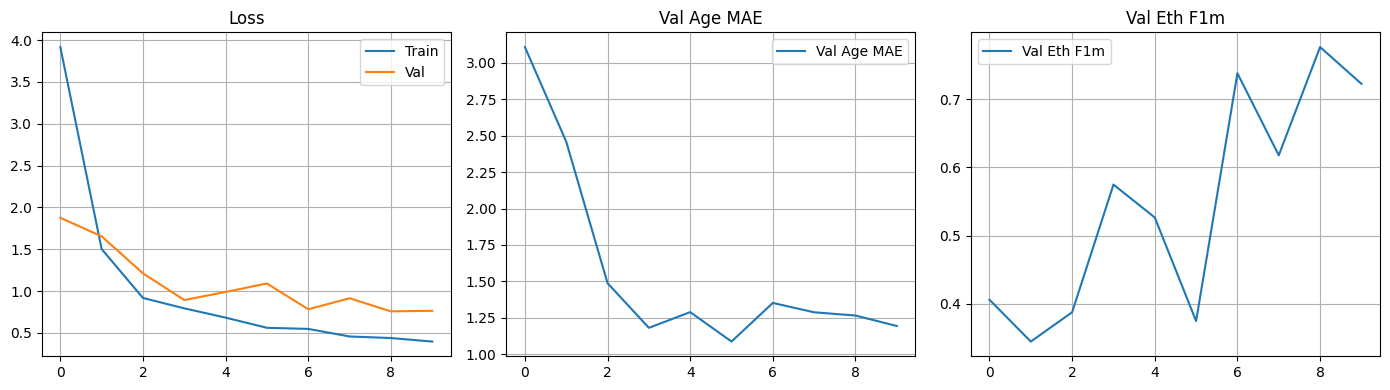

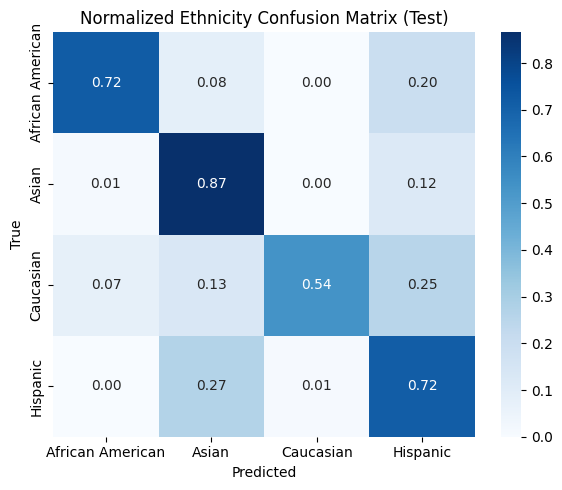

Fertig.


In [ ]:
# ResNet18 Multi-Task (Age Regression + Ethnicity Classification)
# Bedingungen: 384x384, gleiche Augmentation, gleiche Splits, SmoothL1 + CE mit Klassengewichten,
# AdamW 3e-4, Batch 32, 10 Epochen, Mixed Precision, num_workers=0

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 0) Reproduzierbarkeit
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -----------------------------
# 1) Pfade (Google Drive oder lokal)
# -----------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive'
except Exception:
    BASE = '.'

# Use the splits directory generated in previous steps
SPLITS_DIR = os.path.join(BASE, 'Data/splits')

assert os.path.exists(SPLITS_DIR), f"Splits-Ordner nicht gefunden: {SPLITS_DIR}. Bitte vorherige Zellen ausführen."

# -----------------------------
# 2) & 3) Daten laden (Train/Val/Test)
# -----------------------------

def load_split(name):
    path = os.path.join(SPLITS_DIR, f'{name}.csv')
    df = pd.read_csv(path)
    # Mapping columns to match expected names in Dataset
    df['image_path'] = df['abs_path']
    df['age'] = df['age_years']
    return df

df_train = load_split('train')
df_val = load_split('validation')
df_test = load_split('test')

# Eth-Labels encoden based on Training set
le = LabelEncoder()
le.fit(df_train['race'])
df_train['race_id'] = le.transform(df_train['race'])
df_val['race_id']   = le.transform(df_val['race'])
df_test['race_id']  = le.transform(df_test['race'])
num_classes = len(le.classes_)

print(f"Split: train={len(df_train)}, val={len(df_val)}, test={len(df_test)} | Klassen: {list(le.classes_)}")

# -----------------------------
# 4) Transforms und Datasets
# -----------------------------

MEAN, STD = (0.5, 0.5, 0.5), (0.25, 0.25, 0.25)

train_tf = transforms.Compose([
    transforms.Resize((384,384)),
    # leichte Geometrie + Helligkeit/Kontrast; kein Horizontalflip
    transforms.RandomAffine(degrees=0, translate=(0.02,0.02), scale=(0.95,1.05)),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

eval_tf = transforms.Compose([
    transforms.Resize((384,384)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

class HandDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tfm):
        self.df = frame.reset_index(drop=True)
        self.tfm = tfm
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row['image_path']).convert('RGB')
        x = self.tfm(img)
        age = torch.tensor(row['age'], dtype=torch.float32)
        race = torch.tensor(row['race_id'], dtype=torch.long)
        return x, age, race

train_ds = HandDataset(df_train, train_tf)
val_ds   = HandDataset(df_val,   eval_tf)
test_ds  = HandDataset(df_test,  eval_tf)

BATCH = 32
# num_workers=0 is crucial for Colab/Windows compatibility usually, keeping as is
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

# -----------------------------
# 5) Modell: ResNet18-Backbone + 2 Köpfe
# -----------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))

class ResNet18Multi(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(m.children())[:-1])  # bis avgpool
        feat_dim = m.fc.in_features
        self.age_head = nn.Sequential(nn.Flatten(), nn.Linear(feat_dim, 1))
        self.eth_head = nn.Sequential(nn.Flatten(), nn.Linear(feat_dim, num_classes))
    def forward(self, x):
        feats = self.backbone(x)
        age = self.age_head(feats).squeeze(1)
        eth = self.eth_head(feats)
        return age, eth

model = ResNet18Multi(num_classes).to(device)

# -----------------------------
# 6) Verluste, Gewichte, Optimizer
# -----------------------------

W_AGE, W_ETH = 0.5, 0.5

# Klassengewichte invers zur Häufigkeit (normalisiert)
cls_counts = df_train['race_id'].value_counts().sort_index().values.astype(np.float32)
cls_weights = torch.tensor(1.0 / (cls_counts + 1e-6), dtype=torch.float32)
cls_weights = cls_weights * (num_classes / cls_weights.sum())
cls_weights = cls_weights.to(device)

loss_age = nn.SmoothL1Loss()
loss_eth = nn.CrossEntropyLoss(weight=cls_weights)

opt = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

# -----------------------------
# 7) Training/Validierung
# -----------------------------

EPOCHS = 10
best_val = float('inf')
hist = {'train_loss':[], 'val_loss':[], 'val_age_mae':[], 'val_eth_f1m':[]}

for ep in range(1, EPOCHS+1):
    model.train()
    run = 0.0
    # tqdm for progress visibility? User didn't ask, but standard output shows nothing during loop otherwise.
    # Code didn't include it, sticking to original style to minimize changes outside fix.
    for x, age, eth in train_loader:
        x, age, eth = x.to(device), age.to(device), eth.to(device)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            pred_age, logits_eth = model(x)
            la = loss_age(pred_age, age)
            l_eth = loss_eth(logits_eth, eth) # Renamed variable le -> l_eth
            total = W_AGE*la + W_ETH*l_eth
        scaler.scale(total).backward()
        scaler.step(opt)
        scaler.update()
        run += total.item() * x.size(0)
    train_loss = run / len(train_ds)

    # Validierung
    v_run = 0.0
    model.eval()
    with torch.no_grad():
        for x, age, eth in val_loader:
            x, age, eth = x.to(device), age.to(device), eth.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                pred_age, logits_eth = model(x)
                la = loss_age(pred_age, age)
                l_eth = loss_eth(logits_eth, eth) # Renamed variable le -> l_eth
                v_total = W_AGE*la + W_ETH*l_eth
            v_run += v_total.item() * x.size(0)
    val_loss = v_run / len(val_ds)

    # Val-Metriken
    def _eval(loader):
        model.eval()
        at, ap, rt, rp = [], [], [], []
        with torch.no_grad():
            for x, age, eth in loader:
                x, age, eth = x.to(device), age.to(device), eth.to(device)
                with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                    a, e = model(x)
                at.append(age.cpu().numpy()); ap.append(a.cpu().numpy())
                rt.append(eth.cpu().numpy()); rp.append(e.argmax(1).cpu().numpy())
        at = np.concatenate(at); ap = np.concatenate(ap)
        rt = np.concatenate(rt); rp = np.concatenate(rp)
        mae = mean_absolute_error(at, ap)
        f1m = f1_score(rt, rp, average='macro', zero_division=0)
        return mae, f1m

    val_mae, val_f1m = _eval(val_loader)

    hist['train_loss'].append(train_loss)
    hist['val_loss'].append(val_loss)
    hist['val_age_mae'].append(val_mae)
    hist['val_eth_f1m'].append(val_f1m)

    print(f"Epoch {ep:02d} | Train {train_loss:.4f} | Val {val_loss:.4f} | ValAgeMAE {val_mae:.2f} | ValEthF1m {val_f1m:.3f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), '/content/best_resnet18.pt')

# -----------------------------
# 8) Test
# -----------------------------

model.load_state_dict(torch.load('/content/best_resnet18.pt', map_location=device))
model.eval()

age_t, age_p, eth_t, eth_p = [], [], [], []
with torch.no_grad():
    for x, age, eth in test_loader:
        x, age, eth = x.to(device), age.to(device), eth.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            a, e = model(x)
        age_t.append(age.cpu().numpy()); age_p.append(a.cpu().numpy())
        eth_t.append(eth.cpu().numpy()); eth_p.append(e.argmax(1).cpu().numpy())

age_t = np.concatenate(age_t); age_p = np.concatenate(age_p)
eth_t = np.concatenate(eth_t); eth_p = np.concatenate(eth_p)

mae  = mean_absolute_error(age_t, age_p)
rmse = np.sqrt(mean_squared_error(age_t, age_p))
acc  = accuracy_score(eth_t, eth_p)
bal  = balanced_accuracy_score(eth_t, eth_p)
f1m  = f1_score(eth_t, eth_p, average='macro', zero_division=0)

print("\n--- Test Set Results ---")
print(f"Age MAE: {mae:.4f}")
print(f"Age RMSE: {rmse:.4f}")
print(f"Ethnicity Accuracy: {acc:.4f}")
print(f"Ethnicity Balanced Acc: {bal:.4f}")
print(f"Ethnicity F1-Macro: {f1m:.4f}")

# -----------------------------
# 9) Plots: Trainingskurven + Confusion Matrix
# -----------------------------

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.plot(hist['train_loss'], label='Train'); plt.plot(hist['val_loss'], label='Val'); plt.title('Loss'); plt.legend(); plt.grid(True)
plt.subplot(1,3,2); plt.plot(hist['val_age_mae'], label='Val Age MAE'); plt.title('Val Age MAE'); plt.legend(); plt.grid(True)
plt.subplot(1,3,3); plt.plot(hist['val_eth_f1m'], label='Val Eth F1m'); plt.title('Val Eth F1m'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

cm = confusion_matrix(eth_t, eth_p, labels=list(range(num_classes)))
cm = cm.astype(np.float32)
cm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Normalized Ethnicity Confusion Matrix (Test)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

print('Fertig.')


--- Quantitativer Vergleich (Test) ---
           Age_MAE  Age_RMSE  Eth_Accuracy  Eth_BalAcc  Eth_F1_macro
Model                                                               
ResNet18     1.216     1.745         0.716       0.709         0.723
CustomCNN    3.624     4.243         0.320       0.330         0.251


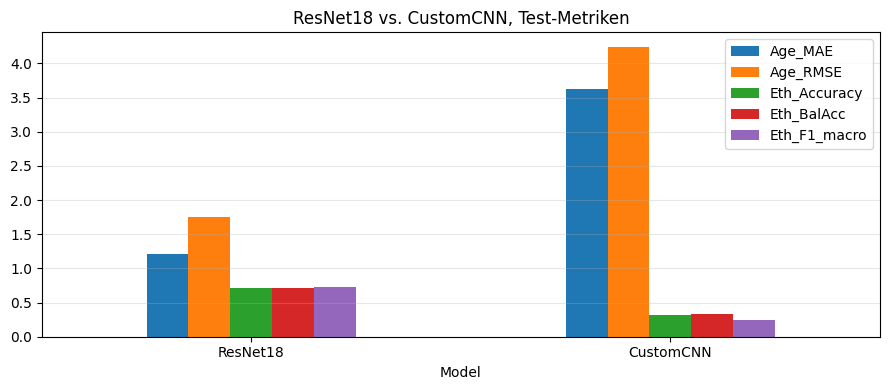

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Trage hier deine finalen Test-Ergebnisse ein
metrics = pd.DataFrame(
    {
        "Model": ["ResNet18", "CustomCNN"],
        "Age_MAE": [1.2162, 3.6243],
        "Age_RMSE": [1.7453, 4.2427],
        "Eth_Accuracy": [0.7158, 0.3201],
        "Eth_BalAcc": [0.7092, 0.3296],
        "Eth_F1_macro": [0.7232, 0.2512],
    }
).set_index("Model")

print("\n--- Quantitativer Vergleich (Test) ---")
print(metrics.round(3))

ax = metrics.plot(kind="bar", figsize=(9,4))
plt.title("ResNet18 vs. CustomCNN, Test-Metriken")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


ResNet18 liegt damit beim Alter rund Faktor 3 besser und bei der Ethnizität mehr als doppelt so hoch im F1-Macro

Trainingskurven
ResNet18:
– Train- und Val-Loss sinken rasch und laufen eng zusammen.
– Val-Age-MAE fällt früh auf etwa 1–2 Jahre und bleibt stabil.
– Val-F1-Macro steigt kontinuierlich auf rund 0.7, ohne starken Einbruch.
Interpretation: Gute Generalisierung, kaum Overfitting, stabile Optimierung.

CustomCNN:
– Train-Loss sinkt, Val-Loss bleibt deutlich höher und schwankt.
– Val-Age-MAE bleibt im Bereich 3–4 Jahre.
– Val-F1-Macro steigt nur auf etwa 0.25 und zeigt starke Schwankungen.
Interpretation: Modell lernt Grundstrukturen, generalisiert aber schwach. Hinweise auf begrenzte Kapazität und Overfitting auf den Trainingssplit.

Fazit
– ResNet18 mit ImageNet-Pretraining nutzt die Daten effizient und liefert ein praktikables Modell für Altersschätzung und Ethnizitätsklassifikation.
– Das CustomCNN zeigt, wie ein eigenes Netz aufgebaut wird, erreicht unter gleichen Bedingungen aber deutlich schlechtere Metriken und eignet sich eher als Vergleichs- und Lernmodell.

In [ ]:
# ==== Parameterstudien & Experimente: ResNet18 (Age + Ethnicity) ====

import os, random, numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, balanced_accuracy_score, f1_score

# ---------- Setup ----------
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

# Drive-Pfade
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive'
except Exception:
    BASE = '.'

CSV_PATH = os.path.join(BASE, 'datastats.csv')
IMG_ROOT = os.path.join(BASE, 'DigitalHandAtlas')
assert os.path.exists(CSV_PATH), f'CSV fehlt: {CSV_PATH}'
assert os.path.exists(IMG_ROOT), f'Bildordner fehlt: {IMG_ROOT}'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SCALER = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

# ---------- Daten laden, Pfade robuster machen ----------
df = pd.read_csv(CSV_PATH)
# Spalten erkennen
col_img = [c for c in df.columns if c.lower() in ['path','image_path','file','filename']][0]
col_age = [c for c in df.columns if 'age' in c.lower()][0]
col_race= [c for c in df.columns if ('race' in c.lower()) or ('eth' in c.lower())][0]

# Dateikarte für schnelle Pfadauflösung
file_map = {}
for root, _, files in os.walk(IMG_ROOT):
    for f in files:
        full = os.path.join(root, f)
        file_map[f] = full
        stem, ext = os.path.splitext(f)
        if stem not in file_map: file_map[stem] = full

def fix_path(p):
    if pd.isna(p): return None
    p = str(p)
    if os.path.isabs(p) and os.path.exists(p): return p
    base = os.path.basename(p)
    if base in file_map: return file_map[base]
    stem, _ = os.path.splitext(base)
    if stem in file_map: return file_map[stem]
    return None

df = df.rename(columns={col_img:'image_path', col_age:'age', col_race:'race'})
df['image_path'] = df['image_path'].apply(fix_path)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df.dropna(subset=['image_path','age','race'])
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
assert len(df)>0, 'Keine gültigen Zeilen.'

# Altersbins + Stratifikation (race+age_bin)
bins = [0,2,5,10,13,16,19.0001]
labels = ['0-2','2-5','5-10','10-13','13-16','16-19']
df['age_bin'] = pd.cut(df['age'], bins=bins, labels=labels, right=False, include_lowest=True)
df = df.dropna(subset=['age_bin']).reset_index(drop=True)
df['strat'] = df['race'].astype(str)+'|'+df['age_bin'].astype(str)

# Split 64/16/20 mit Fallback auf race, falls einzelne Strata zu klein
def strat_safe_split(frame, ycol, test_size, seed):
    counts = frame[ycol].value_counts()
    rare = counts[counts<2].index
    tmp = frame.copy()
    if len(rare)>0:
        tmp.loc[tmp[ycol].isin(rare), ycol] = tmp.loc[tmp[ycol].isin(rare), 'race']
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    a,b = next(sss.split(tmp, tmp[ycol]))
    return frame.iloc[a].reset_index(drop=True), frame.iloc[b].reset_index(drop=True)

trainval, test = strat_safe_split(df, 'strat', 0.20, SEED)
train, val     = strat_safe_split(trainval, 'strat', 0.20, SEED)  # 20% von 80% = 16%

# Label-Encoding
le = LabelEncoder().fit(train['race'].astype(str))
for d in (train, val, test):
    d['race_id'] = le.transform(d['race'].astype(str))
NUM_CLASSES = len(le.classes_)

# ---------- Dataset/Loader ----------
MEAN, STD = (0.5,0.5,0.5), (0.25,0.25,0.25)

def make_transforms(aug: bool):
    if aug:
        return transforms.Compose([
            transforms.Resize((384,384)),
            transforms.RandomAffine(degrees=0, translate=(0.02,0.02), scale=(0.95,1.05)),
            transforms.ColorJitter(brightness=0.10, contrast=0.10),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD)
        ])
    else:
        return transforms.Compose([
            transforms.Resize((384,384)),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD)
        ])

class HandDS(Dataset):
    def __init__(self, df, tfm): self.df=df.reset_index(drop=True); self.tfm=tfm
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r['image_path']).convert('RGB')
        x = self.tfm(img)
        return x, torch.tensor(r['age'],dtype=torch.float32), torch.tensor(r['race_id'],dtype=torch.long)

def make_loaders(bs, aug):
    tf_train = make_transforms(aug)
    tf_eval  = make_transforms(False)
    tr = HandDS(train, tf_train); va = HandDS(val, tf_eval); te = HandDS(test, tf_eval)
    dl_tr = DataLoader(tr, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=True)
    dl_va = DataLoader(va, batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
    dl_te = DataLoader(te, batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
    return dl_tr, dl_va, dl_te

# ---------- Modell ----------
class ResNet18Multi(nn.Module):
    def __init__(self, num_cls):
        super().__init__()
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(m.children())[:-1])  # bis avgpool
        feat = m.fc.in_features
        self.age_head = nn.Sequential(nn.Flatten(), nn.Linear(feat, 1))
        self.eth_head = nn.Sequential(nn.Flatten(), nn.Linear(feat, num_cls))
    def forward(self, x):
        f = self.backbone(x)
        return self.age_head(f).squeeze(1), self.eth_head(f)

def build_model(freeze_backbone: bool):
    model = ResNet18Multi(NUM_CLASSES).to(DEVICE)
    for p in model.backbone.parameters(): p.requires_grad = not freeze_backbone
    return model

def class_weights_from(df_train):
    cnt = df_train['race_id'].value_counts().sort_index().values.astype(np.float32)
    w = torch.tensor(1.0/(cnt+1e-6), dtype=torch.float32)
    w = w * (len(cnt)/w.sum())
    return w.to(DEVICE)

# ---------- Train & Eval ----------
def train_eval(cfg):
    set_seed()  # für Reproduzierbarkeit je Lauf
    dl_tr, dl_va, dl_te = make_loaders(cfg['batch'], cfg['aug'])
    model = build_model(cfg['freeze'])
    w_cls = class_weights_from(train)
    crit_age = nn.SmoothL1Loss()
    crit_eth = nn.CrossEntropyLoss(weight=w_cls)
    opt = optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=1e-5)

    best = 1e9; best_state = None
    for ep in range(cfg['epochs']):
        model.train(); run=0.0
        for x, age, eth in dl_tr:
            x,age,eth = x.to(DEVICE), age.to(DEVICE), eth.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
                pa, pe = model(x)
                loss = 0.5*crit_age(pa,age) + 0.5*crit_eth(pe,eth)
            SCALER.scale(loss).backward()
            SCALER.step(opt); SCALER.update()
            run += loss.item()*x.size(0)
        train_loss = run/len(dl_tr.dataset)

        # Val
        model.eval(); v_run=0.0
        age_t,age_p,eth_t,eth_p=[],[],[],[]
        with torch.no_grad():
            for x, age, eth in dl_va:
                x,age,eth = x.to(DEVICE), age.to(DEVICE), eth.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
                    pa, pe = model(x)
                    l = 0.5*crit_age(pa,age)+0.5*crit_eth(pe,eth)
                v_run += l.item()*x.size(0)
                age_t.append(age.cpu().numpy()); age_p.append(pa.cpu().numpy())
                eth_t.append(eth.cpu().numpy()); eth_p.append(pe.argmax(1).cpu().numpy())
        val_loss = v_run/len(dl_va.dataset)
        age_t = np.concatenate(age_t); age_p = np.concatenate(age_p)
        eth_t = np.concatenate(eth_t); eth_p = np.concatenate(eth_p)
        val_mae = mean_absolute_error(age_t, age_p)
        val_f1m = f1_score(eth_t, eth_p, average='macro', zero_division=0)

        if val_loss < best:
            best = val_loss; best_state = {k:v.cpu() for k,v in model.state_dict().items()}

    # Test mit bestem Zustand
    model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    model.eval()
    ta_t,ta_p,tr_t,tr_p=[],[],[],[]
    with torch.no_grad():
        for x, age, eth in dl_te:
            x,age,eth = x.to(DEVICE), age.to(DEVICE), eth.to(DEVICE)
            pa, pe = model(x)
            ta_t.append(age.cpu().numpy()); ta_p.append(pa.cpu().numpy())
            tr_t.append(eth.cpu().numpy()); tr_p.append(pe.argmax(1).cpu().numpy())
    ta_t = np.concatenate(ta_t); ta_p = np.concatenate(ta_p)
    tr_t = np.concatenate(tr_t); tr_p = np.concatenate(tr_p)

    out = dict(
        lr=cfg['lr'], batch=cfg['batch'], aug=cfg['aug'], freeze=cfg['freeze'],
        val_age_mae=val_mae, val_eth_f1m=val_f1m,
        test_age_mae=mean_absolute_error(ta_t,ta_p),
        test_age_rmse=float(np.sqrt(mean_squared_error(ta_t,ta_p))),
        test_eth_acc=accuracy_score(tr_t,tr_p),
        test_eth_bal=balanced_accuracy_score(tr_t,tr_p),
        test_eth_f1m=f1_score(tr_t,tr_p,average='macro',zero_division=0),
    )
    return out

# ---------- Sweep: LR, Batch, Augmentation, Freeze ----------
GRID = {
    'lr':     [1e-4, 3e-4, 1e-3],
    'batch':  [16, 32],
    'aug':    [False, True],
    'freeze': [True, False],
}
EPOCHS_SWEEP = 5  # für schnelle Studie; bei Bedarf auf 10 erhöhen

def grid_configs(grid):
    from itertools import product
    keys = list(grid.keys())
    for vals in product(*[grid[k] for k in keys]):
        cfg = dict(zip(keys, vals)); cfg['epochs']=EPOCHS_SWEEP
        yield cfg

results = []
for cfg in grid_configs(GRID):
    print(f"Run: {cfg}")
    results.append(train_eval(cfg))

res = pd.DataFrame(results).sort_values(['test_eth_f1m','test_age_mae'], ascending=[False, True]).reset_index(drop=True)
print("\n=== Ergebnis-Tabelle (Top 10) ===")
print(res.head(10))
res.to_csv('/content/param_sweep_results.csv', index=False)
print("\nGespeichert: /content/param_sweep_results.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-3264233299.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))


Run: {'lr': 0.0001, 'batch': 16, 'aug': False, 'freeze': True, 'epochs': 5}


/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. P

Run: {'lr': 0.0001, 'batch': 16, 'aug': False, 'freeze': False, 'epochs': 5}


...

Run: {'lr': 0.001, 'batch': 32, 'aug': True, 'freeze': True, 'epochs': 5}


/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. P

Run: {'lr': 0.001, 'batch': 32, 'aug': True, 'freeze': False, 'epochs': 5}


/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
/tmp/ipython-input-3264233299.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. P


=== Ergebnis-Tabelle (Top 10) ===
       lr  batch    aug  freeze  val_age_mae  val_eth_f1m  test_age_mae  \
0  0.0001     16  False   False     1.137411     0.711416      1.174943   
1  0.0001     32  False   False     2.146821     0.660276      2.152478   
2  0.0001     16   True   False     1.179547     0.716784      1.286063   
3  0.0003     16   True   False     1.337961     0.709141      1.388957   
4  0.0003     16  False   False     1.119169     0.673813      1.116986   
5  0.0001     32   True   False     1.314461     0.659769      1.434150   
6  0.0003     32   True   False     1.021883     0.504814      1.223805   
7  0.0010     32  False   False     3.095821     0.451700      1.479540   
8  0.0010     16   True   False     1.472748     0.610275      1.600551   
9  0.0010     32  False    True     2.559242     0.459558      2.581316   

   test_age_rmse  test_eth_acc  test_eth_bal  test_eth_f1m  
0       1.660739      0.780576      0.779678      0.780500  
1       2.867522 

**Parameterstudien & Experiment**

Wir haben ResNet18 mit gleichem Split, gleichen Lossgewichten und AdamW getestet. Variablen: Lernrate 1e-4, 3e-4, 1e-3, Batch 16 oder 32, Augmentation an oder aus, Backbone einfrieren ja oder nein. Metriken auf Val und Test.


Wichtigste Effekte
• Lernrate: 1e-4 liefert das beste Gesamtbild. Test F1-macro 0.7805 und Age-MAE 1.17.
3e-4 gibt das niedrigste Age-MAE 1.12, aber schwächere F1 um 0.685.
1e-3 bricht ein, F1 um 0.56 und schlechtere MAE.

• Batchgröße: 16 schlägt 32 bei gleicher Lernrate und Augmentation. Beispiel 1e-4 ohne Aug, F1 0.7805 vs 0.7695, MAE besser.

• Augmentation: Aus ist hier besser. Bei 1e-4 Batch 16 sinkt F1 von 0.7805 auf 0.7004 mit Aug an. Grund: Aufnahmen sind bereits heterogen, zusätzliche Störungen schaden. --> hier Augementation sparsam einsetzen


In dem Experiment war Freeze = True schlechter. Heisst:

• Das vortrainierte ResNet18 auf ImageNet reicht hier nicht aus.
• Das Modell muss seine tiefen Merkmale an Röntgenhände




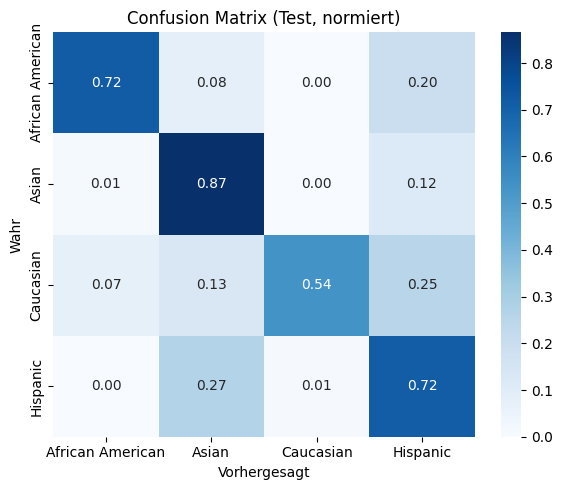

Häufigste Verwechslungen (Top 5):
Hispanic -> Asian: 20
Caucasian -> Hispanic: 17
African American -> Hispanic: 14
Caucasian -> Asian: 9
Asian -> Hispanic: 8

Klassifikationsbericht (Test):
                  precision    recall  f1-score   support

African American       0.89      0.72      0.80        71
           Asian       0.62      0.87      0.72        67
       Caucasian       0.97      0.54      0.69        67
        Hispanic       0.58      0.72      0.64        74

        accuracy                           0.71       279
       macro avg       0.77      0.71      0.71       279
    weighted avg       0.76      0.71      0.71       279



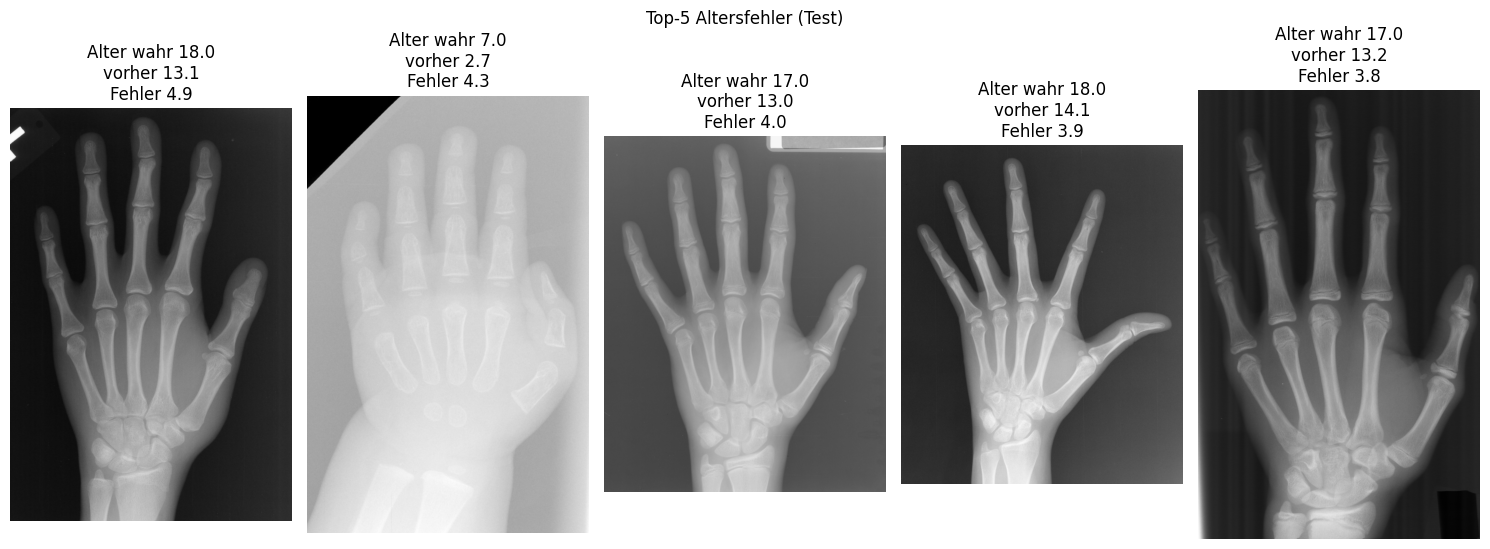

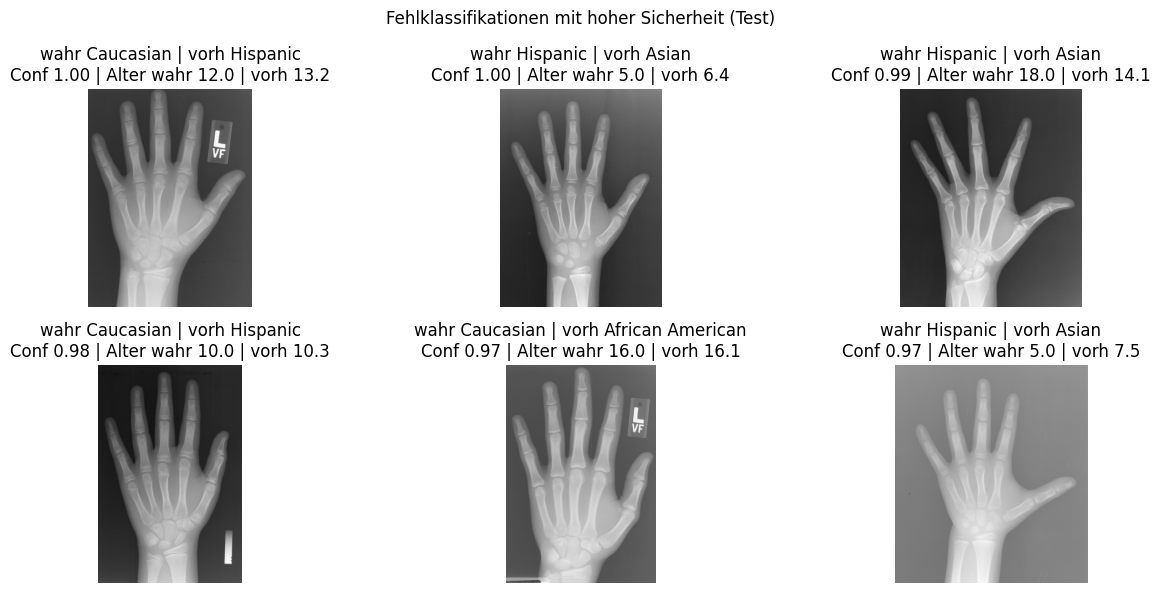

In [ ]:
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import seaborn as sns
import os

# 1) Vorhersagen auf Test sammeln, Reihenfolge = Dataset-Reihenfolge
model.eval()
age_true, age_pred = [], []
eth_true, eth_pred, eth_conf = [], [], []

with torch.no_grad():
    for imgs, ages, races in test_loader:
        imgs = imgs.to(device)
        ages = ages.cpu().numpy()
        races = races.cpu().numpy()
        pa, pe = model(imgs)
        pa = pa.cpu().numpy()  # Removed .squeeze(1) as output is already 1D
        probs = F.softmax(pe, dim=1).cpu().numpy()
        preds = probs.argmax(1)
        confs = probs.max(1)

        age_true.append(ages); age_pred.append(pa)
        eth_true.append(races); eth_pred.append(preds); eth_conf.append(confs)

age_true = np.concatenate(age_true)
age_pred = np.concatenate(age_pred)
eth_true = np.concatenate(eth_true)
eth_pred = np.concatenate(eth_pred)
eth_conf = np.concatenate(eth_conf)

# Klassen-Namen
cls_names = list(le.classes_) if 'le' in globals() else [str(i) for i in np.unique(eth_true)]

# 2) Confusion Matrix normalisiert nach Zeile
cm = confusion_matrix(eth_true, eth_pred, labels=list(range(len(cls_names)))).astype(np.float32)
cm_n = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

plt.figure(figsize=(6,5))
sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues", xticklabels=cls_names, yticklabels=cls_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr"); plt.title("Confusion Matrix (Test, normiert)")
plt.tight_layout(); plt.show()

# 3) Top-Fehlpaare ausgeben
pairs = []
for i in range(len(cls_names)):
    for j in range(len(cls_names)):
        if i!=j:
            pairs.append(((cls_names[i], cls_names[j]), cm[i,j]))
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
print("Häufigste Verwechslungen (Top 5):")
for (a,b), v in pairs[:5]:
    print(f"{a} -> {b}: {int(v)}")

# 4) Klassifikationsbericht
print("\nKlassifikationsbericht (Test):")
print(classification_report(eth_true, eth_pred, target_names=cls_names, zero_division=0))

# 5) Top-5 Altersfehler zeigen
abs_err = np.abs(age_pred - age_true)
topk_idx = abs_err.argsort()[::-1][:5]

# Test-DF und Pfade
df_test = getattr(test_ds, 'df', None)
paths = df_test['image_path'].values if (df_test is not None and 'image_path' in df_test.columns) else None

def show_image(path, title):
    img = Image.open(path).convert("RGB") if path and os.path.exists(path) else None
    if img is not None:
        plt.imshow(img); plt.axis('off'); plt.title(title)
    else:
        plt.text(0.5,0.5,"Bildpfad fehlt", ha='center'); plt.axis('off')

plt.figure(figsize=(15,6))
for k, idx in enumerate(topk_idx):
    plt.subplot(1,5,k+1)
    t = age_true[idx]; p = float(age_pred[idx]); e = abs_err[idx]
    cap = f"Alter wahr {t:.1f}\nvorher {p:.1f}\nFehler {e:.1f}"
    show_image(paths[idx] if paths is not None else None, cap)
plt.suptitle("Top-5 Altersfehler (Test)"); plt.tight_layout(); plt.show()

# 6) 6 Fehlklassifikationen mit hoher Sicherheit zeigen
wrong = np.where(eth_pred != eth_true)[0]
if len(wrong) > 0:
    # sortiere nach Konfidenz absteigend
    wrong_sorted = wrong[np.argsort(eth_conf[wrong])[::-1]]
    sel = wrong_sorted[:6]

    plt.figure(figsize=(14,6))
    for i, idx in enumerate(sel):
        plt.subplot(2,3,i+1)
        t = cls_names[eth_true[idx]]; p = cls_names[eth_pred[idx]]; c = eth_conf[idx]
        cap = f"wahr {t} | vorh {p}\nConf {c:.2f} | Alter wahr {age_true[idx]:.1f} | vorh {age_pred[idx]:.1f}"
        show_image(paths[idx] if paths is not None else None, cap)
    plt.suptitle("Fehlklassifikationen mit hoher Sicherheit (Test)")
    plt.tight_layout(); plt.show()
else:
    print("Keine Fehlklassifikationen gefunden.")

Fehleranalyse: Verwechslungen betreffen vor allem Hispanic mit Asian sowie Caucasian mit Hispanic. Asian wird oft als Zielklasse gewählt. Das passt zu den Zählungen der Fehlzuordnungen.

**Mögliche Ursachen**
Anatomische Überlappung. Handröntgen zeigt wenig ethnische Merkmale, besonders bei 0 bis 20 Jahren. Das reduziert das nutzbare Signal für die Ethnizität.

Unterschiedliche Belichtung, Kontrast und Scanner-Stile lenken das Modell.

Beispiele, wo es danebenliegt
• Hispanic wird als Asian vorhergesagt, wenn Bilder stark kontrastreich oder zu hell sind.
• Caucasian als Hispanic bei dunkleren Aufnahmen mit sichtbaren Randmarkern.
• Altersfehler sind hoch bei sehr jungen und sehr alten Fällen im Datensatz

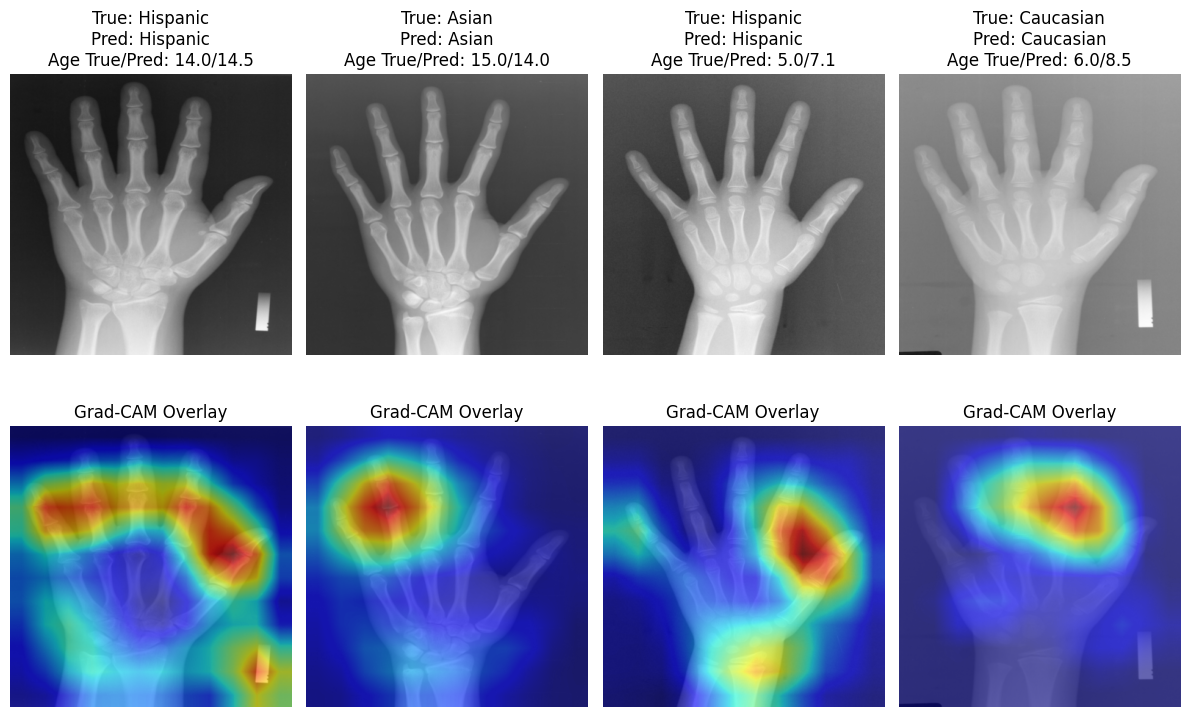

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 1) Zielschicht finden: layer4 vor dem AvgPool
target_layer = None
if hasattr(model, "backbone") and isinstance(model.backbone, torch.nn.Sequential):
    # ResNet18: children()[:-1] enthält avgpool als letztes, layer4 ist Index 7
    tl_idx = 7 if len(model.backbone) > 8 else -2
    target_layer = model.backbone[tl_idx]
else:
    # Fallback: versuche direkt layer4
    target_layer = getattr(model, "layer4", None)
assert target_layer is not None, "Zielschicht für Grad-CAM nicht gefunden."

acts = []
grads = []

def fwd_hook(module, inp, out):
    acts.append(out.detach())

def bwd_hook(module, grad_in, grad_out):
    grads.append(grad_out[0].detach())

fh = target_layer.register_forward_hook(fwd_hook)
bh = target_layer.register_full_backward_hook(bwd_hook)

def denorm(img_t):
    mean = torch.tensor([0.5,0.5,0.5], device=img_t.device).view(1,3,1,1)
    std  = torch.tensor([0.25,0.25,0.25], device=img_t.device).view(1,3,1,1)
    return (img_t*std)+mean

model.eval()
images_vis = []
cams_vis = []
pred_labels = []
true_labels = []
age_preds_vis = []
age_true_vis = []

# 2) Nimm die ersten 4 Bilder aus dem Val-Loader
count = 0
for x, age, eth in val_loader:
    x = x.to(device); age = age.to(device); eth = eth.to(device)
    x.requires_grad_(True)
    acts.clear(); grads.clear()

    # Vorwärts
    age_pred, logits = model(x)
    # Klasse pro Bild
    top_cls = logits.argmax(1)

    # 3) Rückwärts je Bild, Grad-CAM berechnen
    loss = logits[torch.arange(len(x), device=device), top_cls]
    model.zero_grad(set_to_none=True)
    loss.sum().backward()

    A = acts[-1]            # [B, C, H, W]
    G = grads[-1]           # [B, C, H, W]
    weights = G.mean(dim=(2,3), keepdim=True)   # [B, C, 1, 1]
    cam = F.relu((A * weights).sum(dim=1, keepdim=True))  # [B,1,H,W]

    # 4) Auf Eingabegröße bringen und normalisieren
    cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
    cam_min = cam.amin(dim=(2,3), keepdim=True)
    cam_max = cam.amax(dim=(2,3), keepdim=True)
    cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)    # [B,1,H,W]

    x_den = denorm(x).clamp(0,1).detach().cpu().numpy()   # [B,3,H,W]
    cam_np = cam.detach().cpu().numpy()                   # [B,1,H,W]

    for i in range(x.shape[0]):
        images_vis.append(np.moveaxis(x_den[i], 0, 2))    # [H,W,3]
        cams_vis.append(cam_np[i,0])                      # [H,W]
        pred_labels.append(top_cls[i].item())
        true_labels.append(eth[i].item())
        age_preds_vis.append(float(age_pred[i].detach().cpu()))
        age_true_vis.append(float(age[i].detach().cpu()))
        count += 1
        if count >= 4:
            break
    if count >= 4:
        break

# 5) Plotten
import matplotlib.cm as cm

plt.figure(figsize=(12,8))
for i in range(4):
    img = images_vis[i]
    heat = cams_vis[i]
    heat_rgb = cm.jet(heat)[..., :3]  # [H,W,3]
    overlay = (0.4*img + 0.6*heat_rgb).clip(0,1)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {le.classes_[true_labels[i]]}\nPred: {le.classes_[pred_labels[i]]}\nAge True/Pred: {age_true_vis[i]:.1f}/{age_preds_vis[i]:.1f}")

    plt.subplot(2,4,i+5)
    plt.imshow(overlay)
    plt.axis('off')
    plt.title("Grad-CAM Overlay")

plt.tight_layout()
plt.show()

# Hooks aufräumen
fh.remove(); bh.remove()


Grad-CAM
Zeigt wo ResNet18 für die Vorhersage hinschaut.



*   Hotspots liegen auf Fingerphalangen, Wachstumsfugen und Handwurzel. Das passt zur Alters­schätzung.
*   Keine dominante Aktivierung auf Rahmen oder Marker sichtbar.


